# Imports

In [1]:
#set path to DeePEn
import os.path

os.chdir("path to DeePEn")

In [2]:
#import dependencies
import copy
import requests
import zipfile
import io
import json
import math
import os
import subprocess
import sys

import numpy as np
import pandas as pd

from scipy import stats
from scipy.interpolate import make_interp_spline

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.pyplot import cm
import matplotlib.ticker as mtick

import seaborn as sns

In [3]:
# import methods
sys.path.append('./utils')
from DeePEn_evaluate import get_cutoff, load_results, calc_spearman_depthwise, calc_metric_depth
from DeePEn_analyse import plot_multi_model_multi_metric_DeePEn, table_multi_model_multi_metric_DeePEn, mean_confidence_interval_individual

In [4]:
# run prepare_data.py if the splits were not created yet
if not os.path.isdir('./data/splits'):
    subprocess.run(['python', './data/prepare_data.py'])

In [5]:
# Check: If ./results exists, contains SOM zip shards, and does NOT contain SOM directory, unzip
main_zip_1 = './results/SOM_1.zip'
main_zip_2 = './results/SOM_2.zip'
main_dir = './results/SOM'

def unzip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        zipf.extractall(extract_to)

if os.path.isdir('./results') and os.path.isfile(main_zip_1) and os.path.isfile(main_zip_2) and not os.path.isdir(main_dir):
    unzip(main_zip_1, main_dir)
    unzip(main_zip_2, main_dir)
    print(f'Extracted {main_zip_1.split("/")[-1]} and {main_zip_2.split("/")[-1]} to {main_dir}')
elif os.path.isdir(main_dir):
    print(f'{main_dir} was already extracted previously')    
else:
    print(f'{main_zip} is missing')

./results/SOM was already extracted previously


# Create display items

In [6]:
# Get a list of all datasets in the directory
files = os.listdir("./data/splits")
files

['CAPSD_AAV2S_Sinai_2021',
 'GFP_AEQVI_Sarkisyan_2016',
 'HIS7_YEAST_Pokusaeva_2019',
 'PHOT_CHLRE_Chen_2023']

## Figures

### Fig. S1

In [7]:
def plot_depthwise(data, data_name, path):
    
    files = os.listdir(path)
    filtered_files = [f for f in files if (data in f) and not ("baseline" in f)]

    depth = list(range(1,len(filtered_files)+1)) 
    
    dfs = []
    
    for d in depth:
        df = calc_spearman_depthwise(path, data, d)
        
        # the Dehydratase, depth 1 run, seed 2 did not converge and gets removed here
        if (data_name == "Dehydratase") and (d == 1):
            df = df.drop(2, axis=1)
            df['mean'] = df[[1,3]].mean(axis=1)
            
        # Identify seed columns (excluding named columns)
        seed_cols = [col for col in df.columns if isinstance(col, int)]
        
        # Calculate standard deviation across numeric columns
        df['std'] = df[seed_cols].std(axis=1)
        
        dfs.append(df)
        
    # Initialize the figure and subplots
    fig, ax = plt.subplots(figsize=(8, 3),dpi=300)

    color=cm.rainbow(np.linspace(0,1,9))
    
    color = color[len(color)-int(depth[-1]):]
    
    # add Baseline plot    
    df = calc_spearman_depthwise(path, data, 0, baseline=True)   
    ax.plot(df['x'], df['mean'], label="Baseline", marker='o', c="lightgrey")
    # Calculate standard deviation across numeric columns
    df['std'] = df[seed_cols].std(axis=1)
    ax.errorbar(df['x'], df['mean'], yerr=df['std'], 
                   fmt='none', c="lightgrey", 
                   capsize=3, capthick=1, elinewidth=1, alpha=0.7) 
    
    # Plot markers and lines first
    for df, d, c in zip(dfs, depth, reversed(color)):
        if d == 1:
            name = str(d)
        else:
            name = "1 - " + str(d)
            
        ax.plot(df['x'], df['mean'], marker='o', markerfacecolor='none', c=c)
        ax.plot(df['x'][1:], df['mean'][1:], label=name, marker='o', c=c)
    
    # Second pass: Add error bars
    for df, d, c in zip(dfs, depth, reversed(color)):
        ax.errorbar(df['x'], df['mean'], yerr=df['std'], 
                   fmt='none', c=c, 
                   capsize=3, capthick=1, elinewidth=1, alpha=0.7)


    ax.set_xticks([0, 1] + list(dfs[0]['x']))
    ax.set_xticklabels(["WT", 1] + list(dfs[0]['depth']))

    ax.set_xlim(1, df['x'].max()+0.1)
    
    # extend the grid for AAV to make the baseline visible
    if data_name == "AAV Capsid":
        ax.set_ylim(-0.5, 1)
        ax.axhline(0, color='grey', linestyle='dashed', linewidth=1)
    else:
        ax.set_ylim(0, 1)
        
    # Add horizontal grid lines
    ax.grid(axis='y', alpha=0.7, linewidth=0.5)
    
    ax.set_xlabel('Mutational Depth')
    ax.set_ylabel('Spearman')

    handles, labels = ax.get_legend_handles_labels()
    # Move Baseline to the end
    new_handles = handles[1:] + [handles[0]]
    new_labels = labels[1:] + [labels[0]]
    ax.legend(new_handles, new_labels, loc='center left', bbox_to_anchor=(1, 0.55), title='Training depth')

    # Adjust layout and show the plot
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    
    ax.set_title(data_name)
    plt.show()

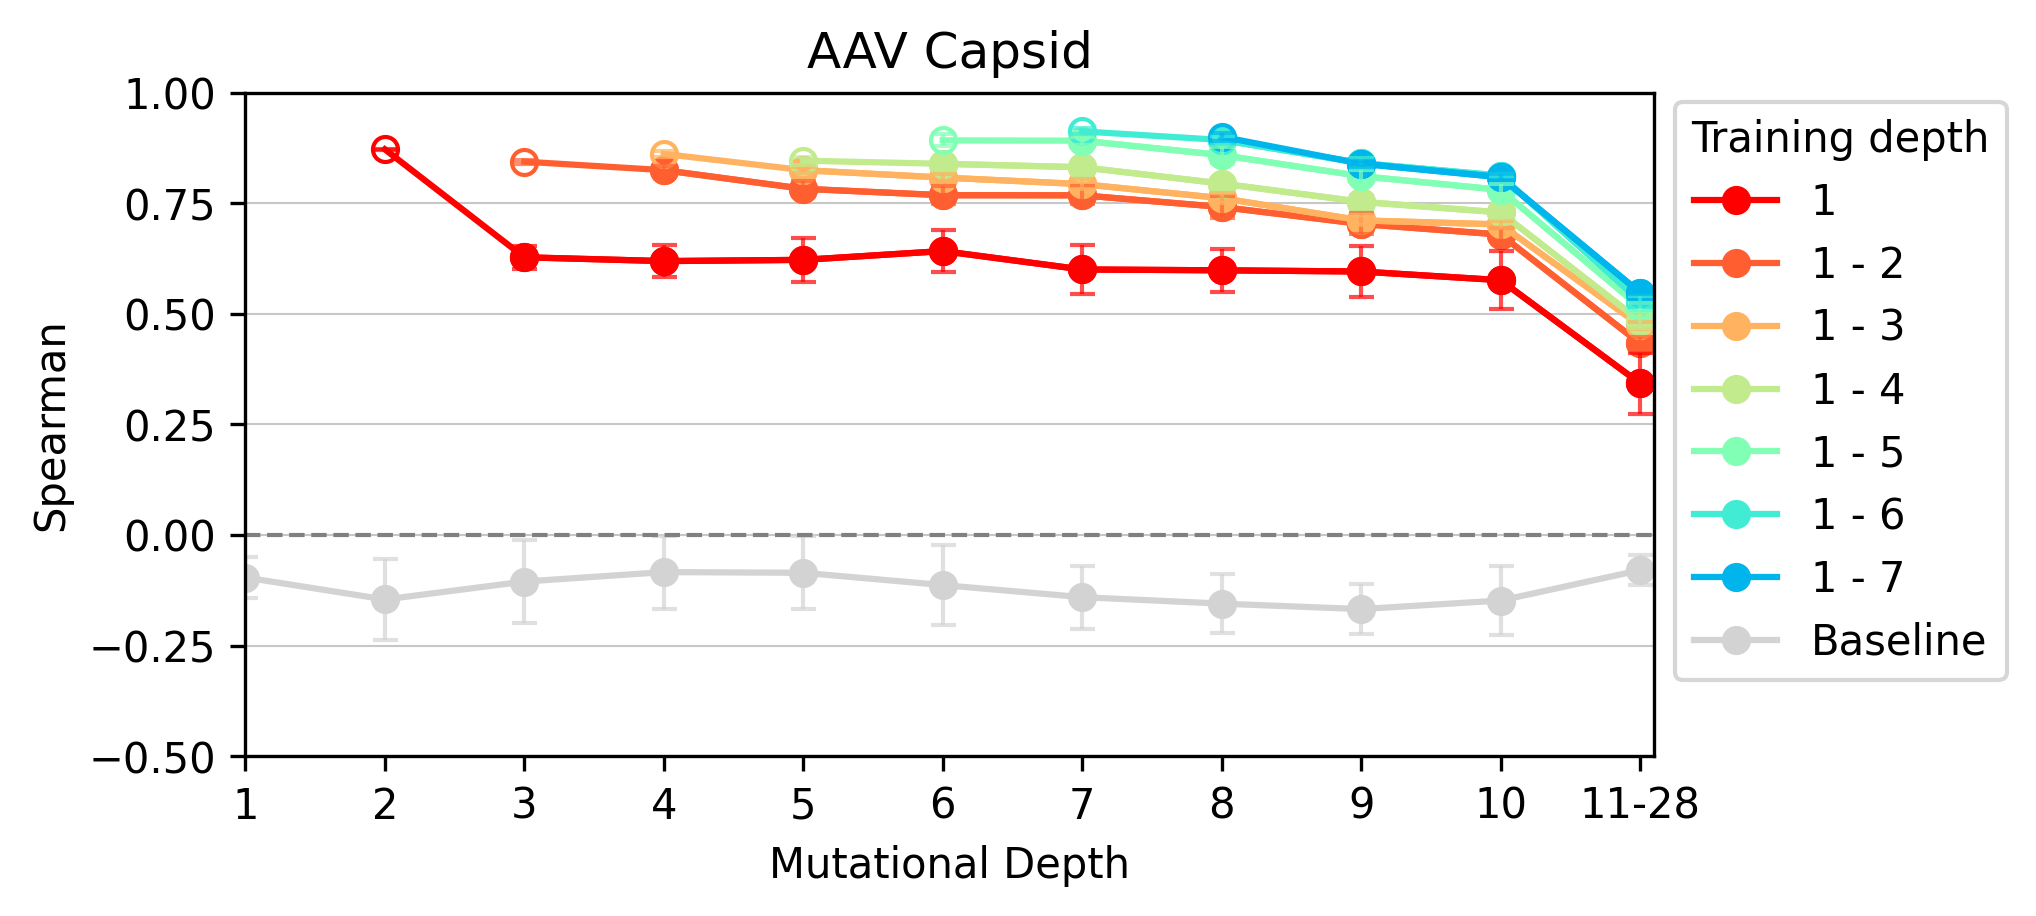

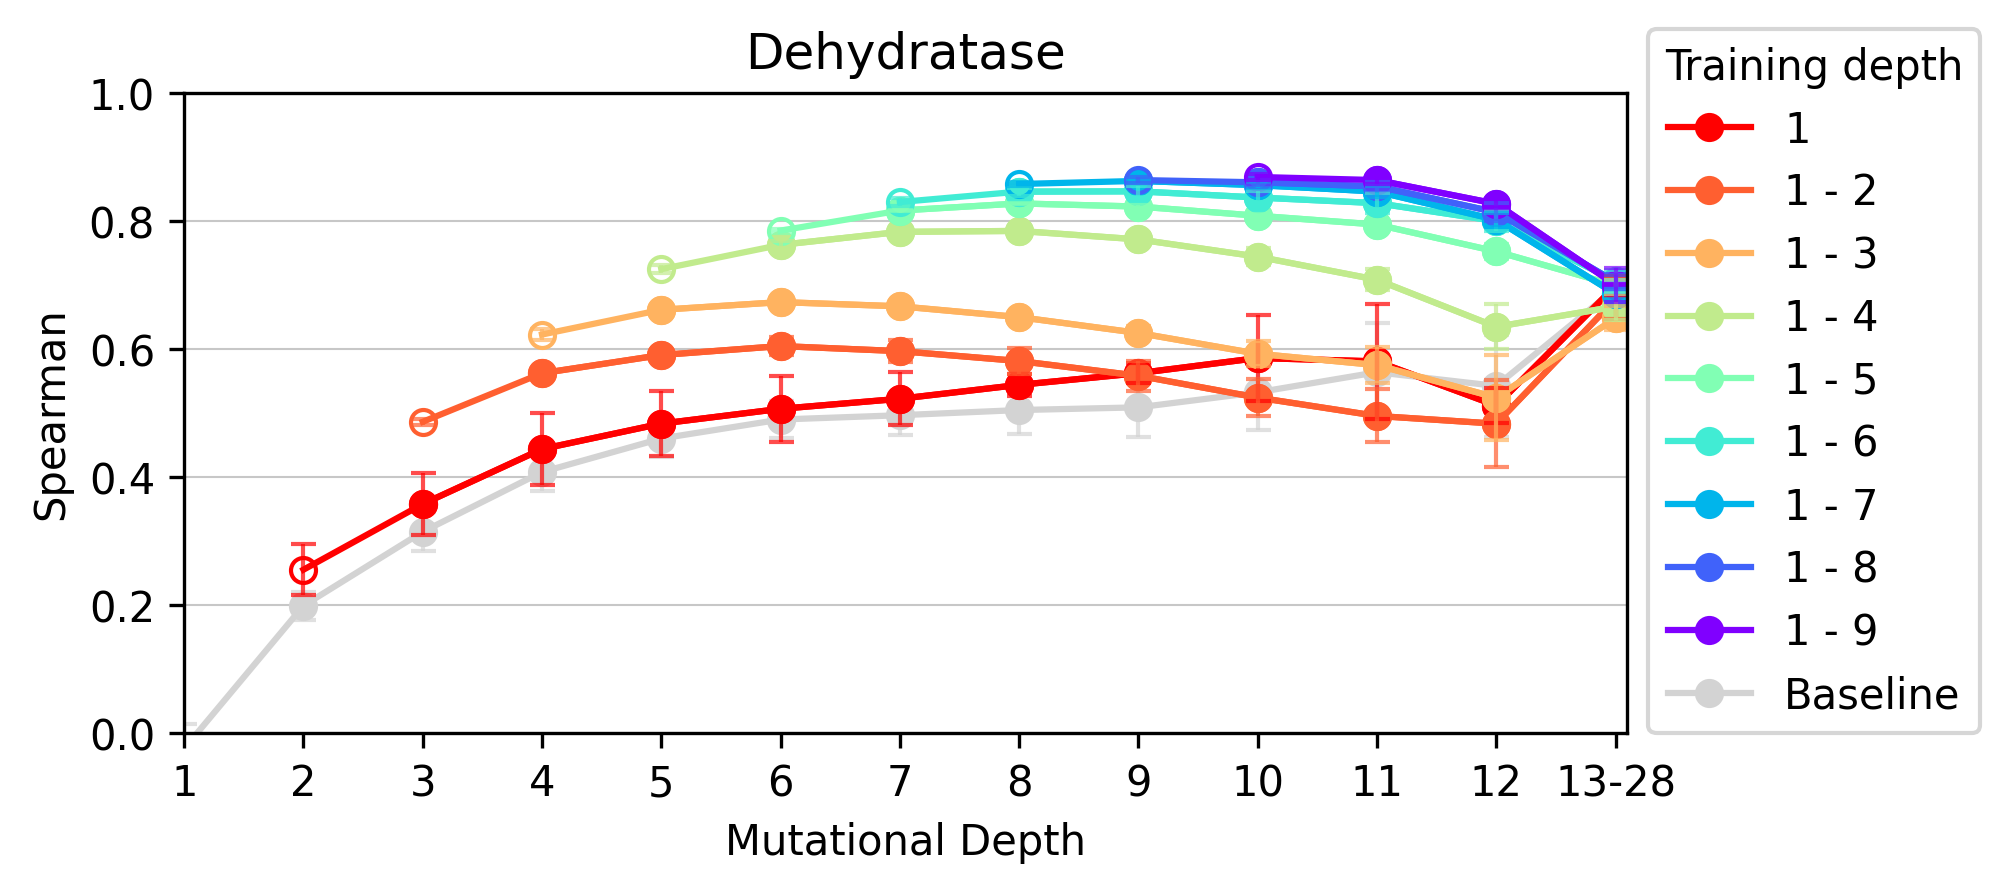

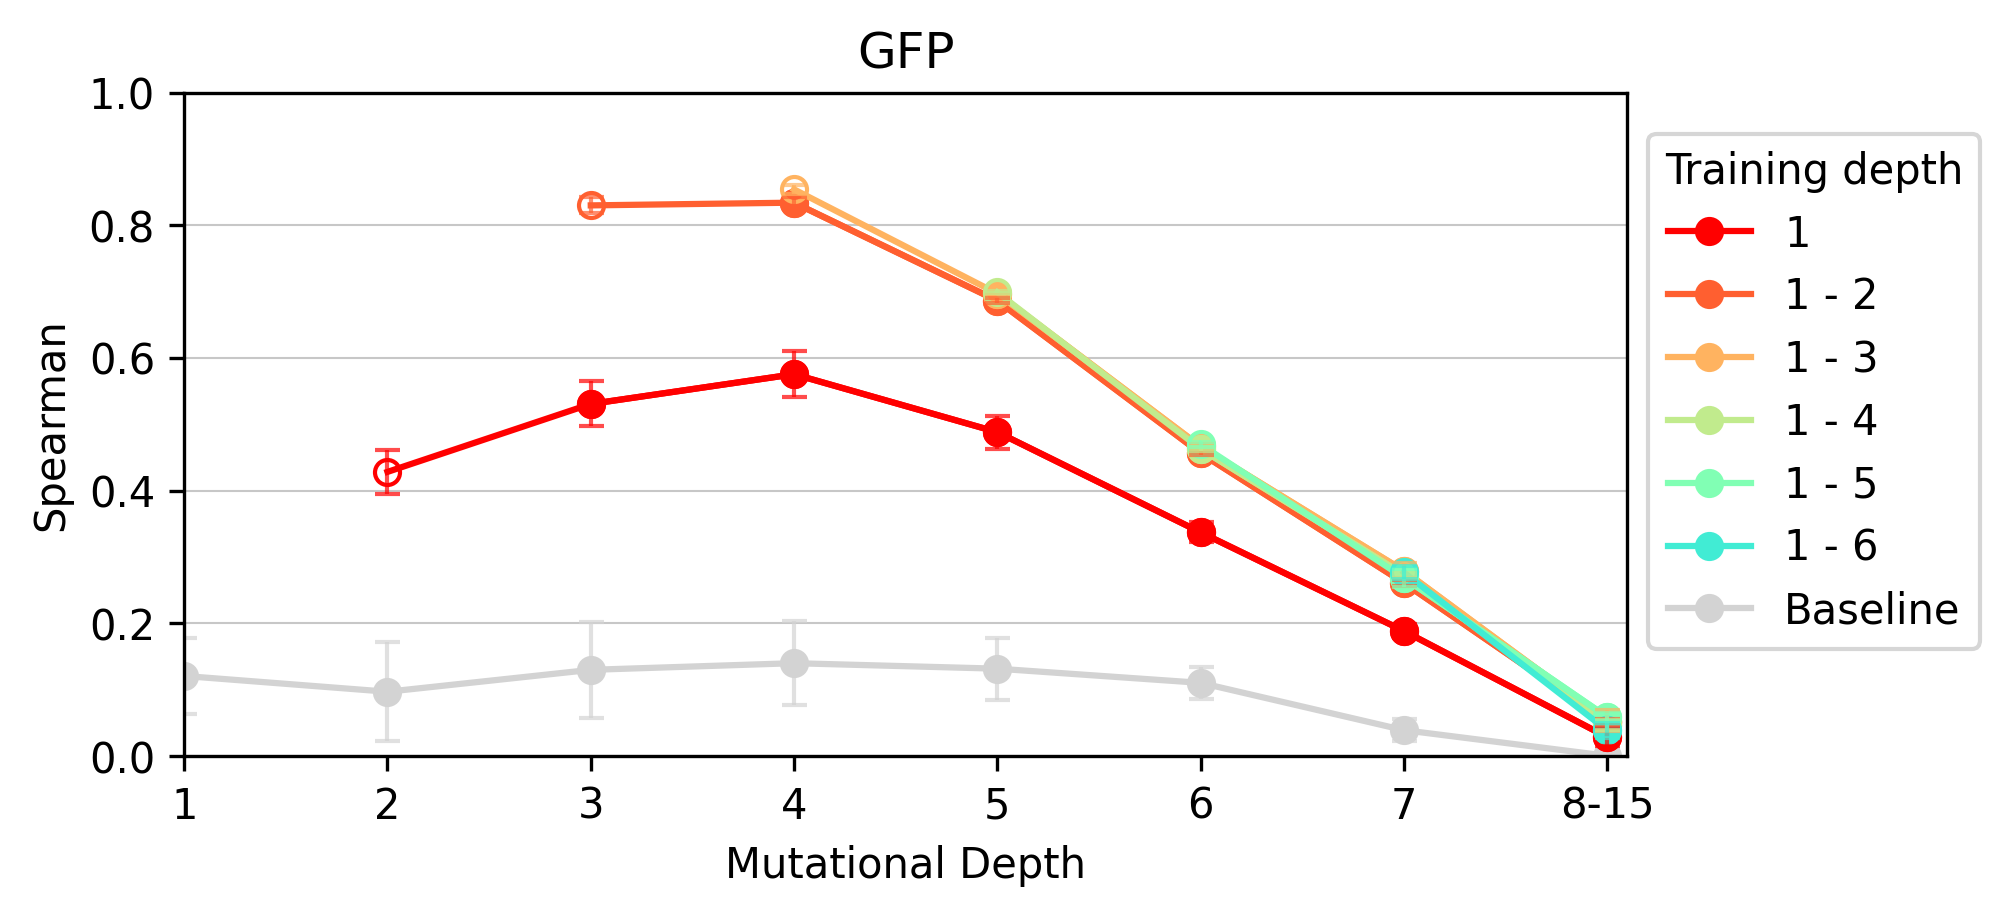

In [8]:
path_SOM_depthwise = "./results/SOM/PT5-LoRA_rank_depthwise"

# plot depthwise for all but PHOT_CHLRE_Chen_2023 
for f, n in zip([files[0],files[2],files[1]], ["AAV Capsid", "Dehydratase", "GFP"]):
    plot_depthwise(f, n, path_SOM_depthwise)

### Fig. S2-S5

In [10]:
models = ['SBI',
         '1-hot',
         'MAVE-NN_add',
         'MAVE-NN_bb',
         'PT5-LoRA_reg',
         'PT5-LoRA_rank',
         'PT5-Emb',
         'PT5-Emb_evo',
         'METL_1D',
         'METL_3D']

In [11]:
files

['CAPSD_AAV2S_Sinai_2021',
 'GFP_AEQVI_Sarkisyan_2016',
 'HIS7_YEAST_Pokusaeva_2019',
 'PHOT_CHLRE_Chen_2023']

In [44]:
# Calculate random and perfect_classifier baseline for individual datasets
# this cell will take an extended amount of time to compute
# read the results directly from the respective csv files in ./results/main/random_baseline/

def round_to_percent(s):
    main, error = map(lambda x: float(x.strip()), s.split('±'))
    main_pct = int(round(main,2) * 100)
    error_pct = int(round(error,2) * 100)
    return f"{main_pct} ± {error_pct}"

for f in files:
    if "GFP" in f:
        df_float = table_multi_model_multi_metric_DeePEn(models,[f],["spearman_all","AUCPR", "spearman_func", "TOP_10", "NDCG@10"], 
                                           random_baseline = True, perfect_classifier_baseline = True, percentage = False, digits = 3)        
    else:
        df_float = table_multi_model_multi_metric_DeePEn(models,[f],["AUCPR", "spearman_func", "TOP_10", "NDCG@10"], 
                                           random_baseline = True, perfect_classifier_baseline = True, percentage = False, digits = 3)

    df_float.to_csv("./results/main/random_baseline/" + f + "_only_float.csv", index=False)
    # get percentage values
    df = df_float.copy()
    for m in ["AUCPR", "spearman_func", "TOP_10", "NDCG@10"]:
        df[m] = df[m].apply(round_to_percent)
    df.to_csv("./results/main/random_baseline/" + f + "_only.csv", index=False)


CAPSD_AAV2S_Sinai_2021


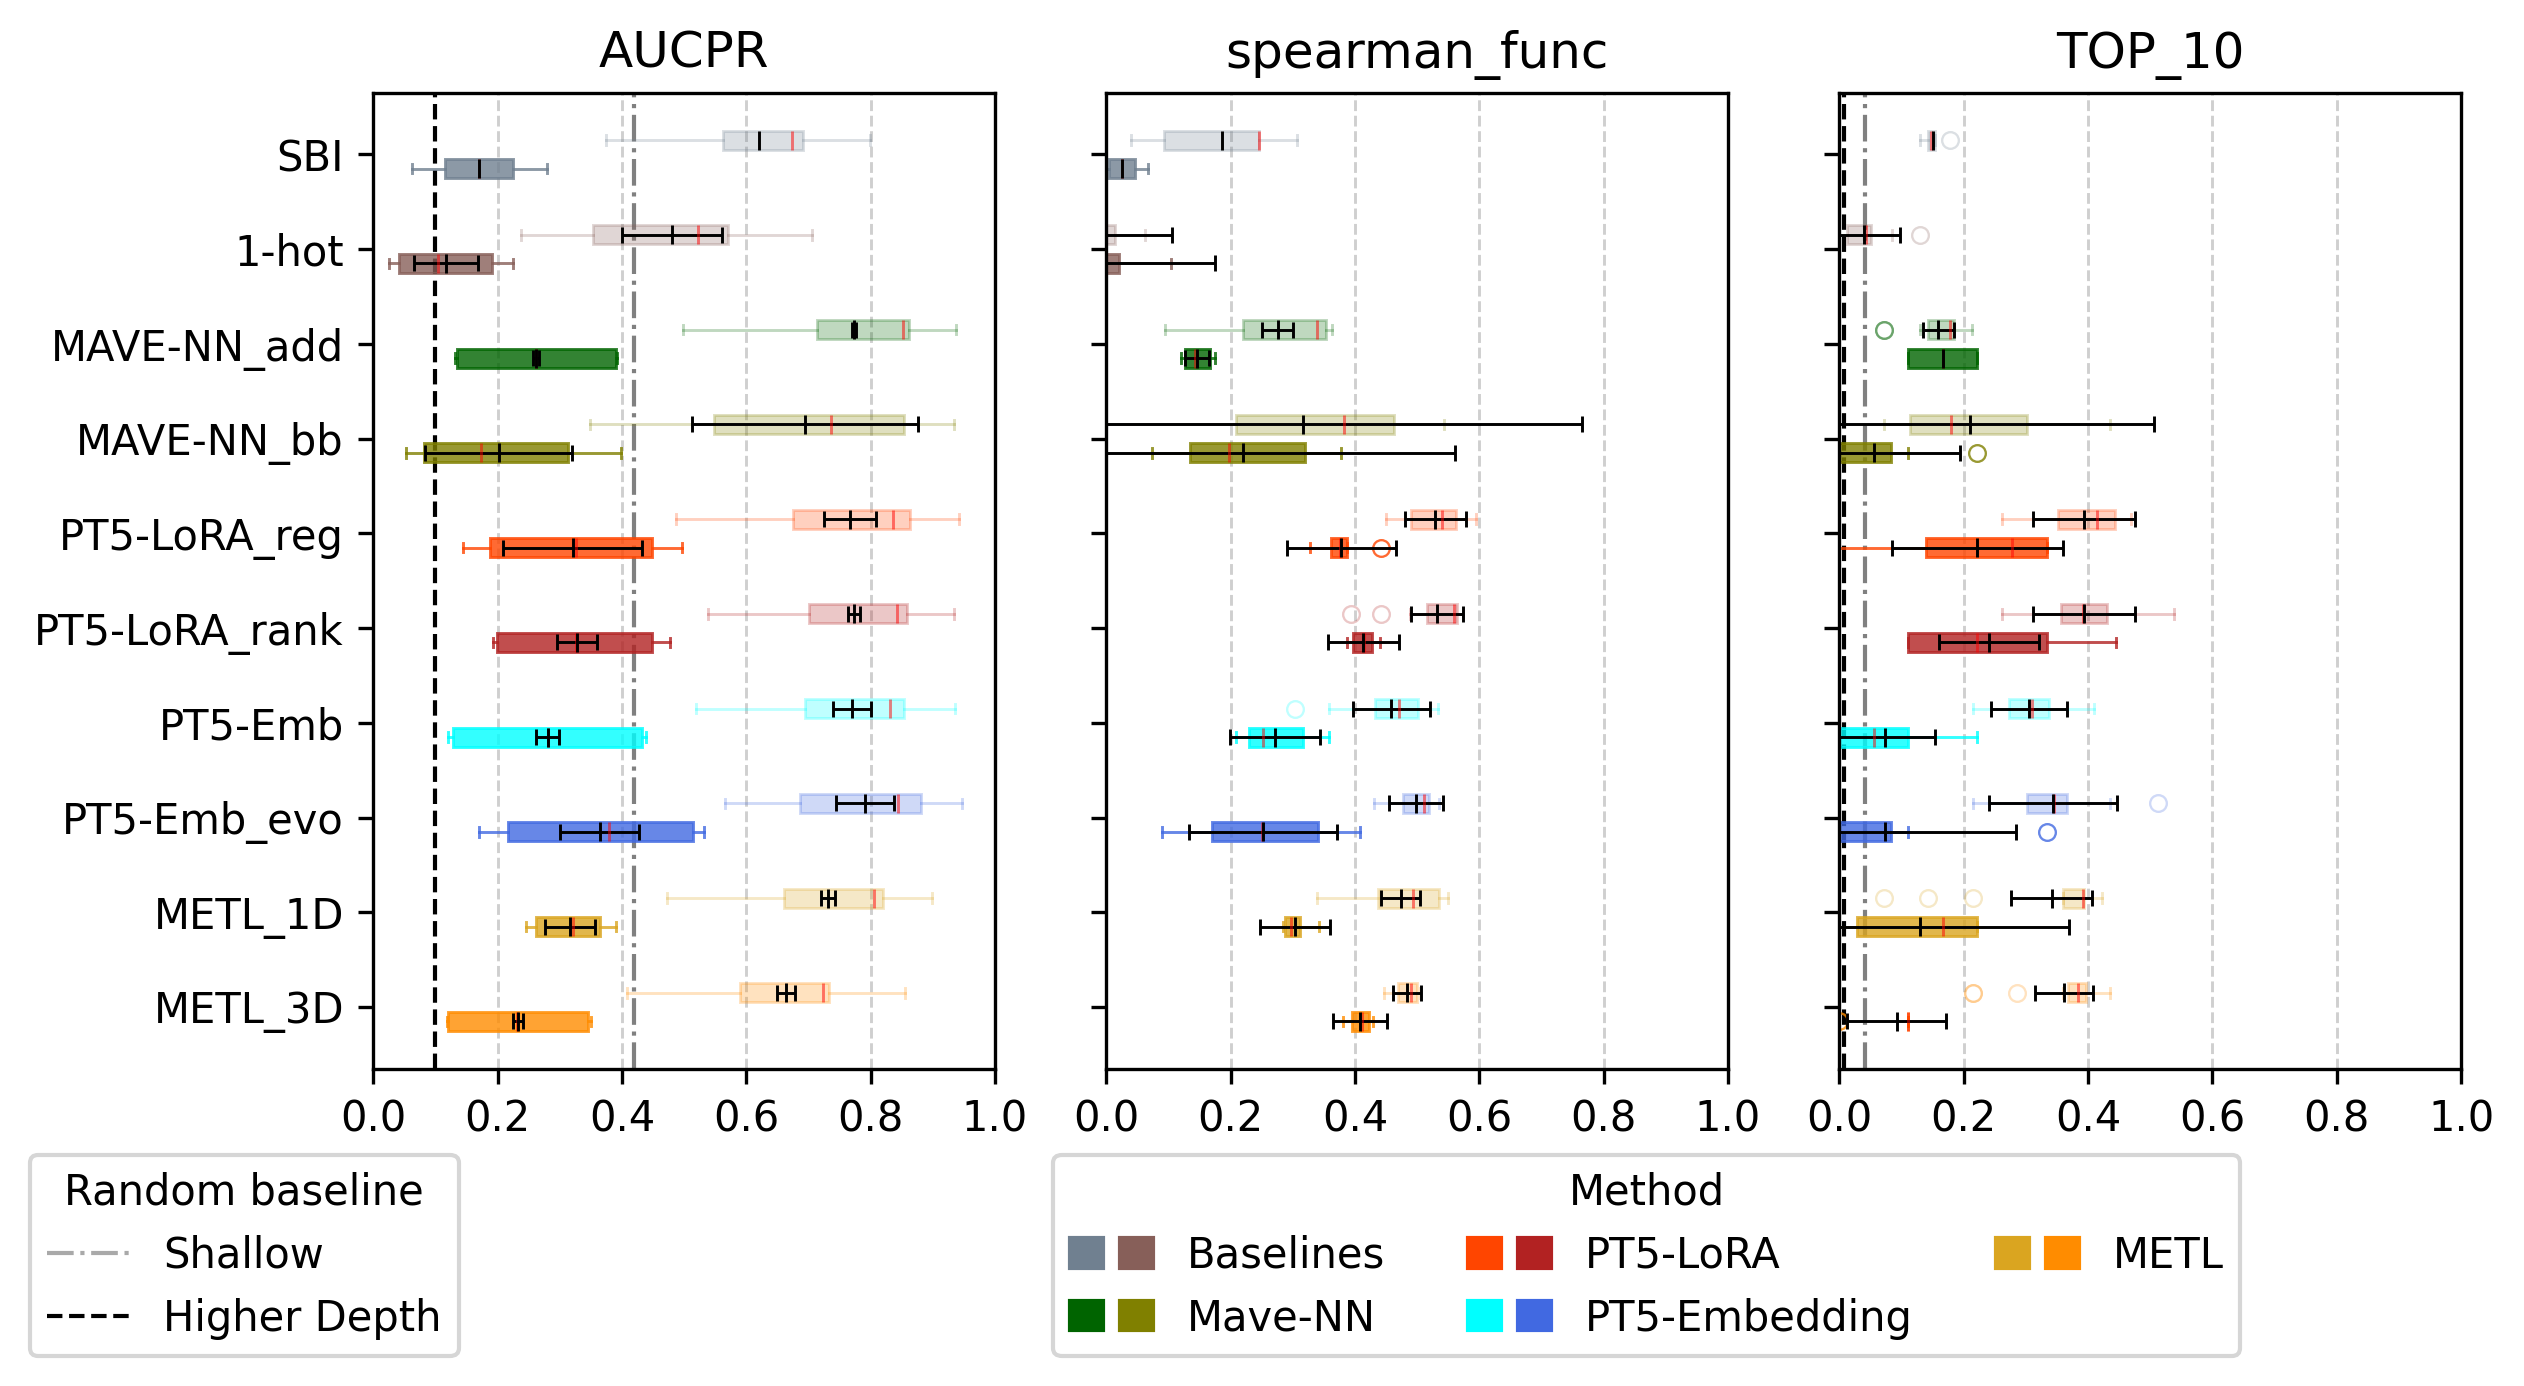

GFP_AEQVI_Sarkisyan_2016


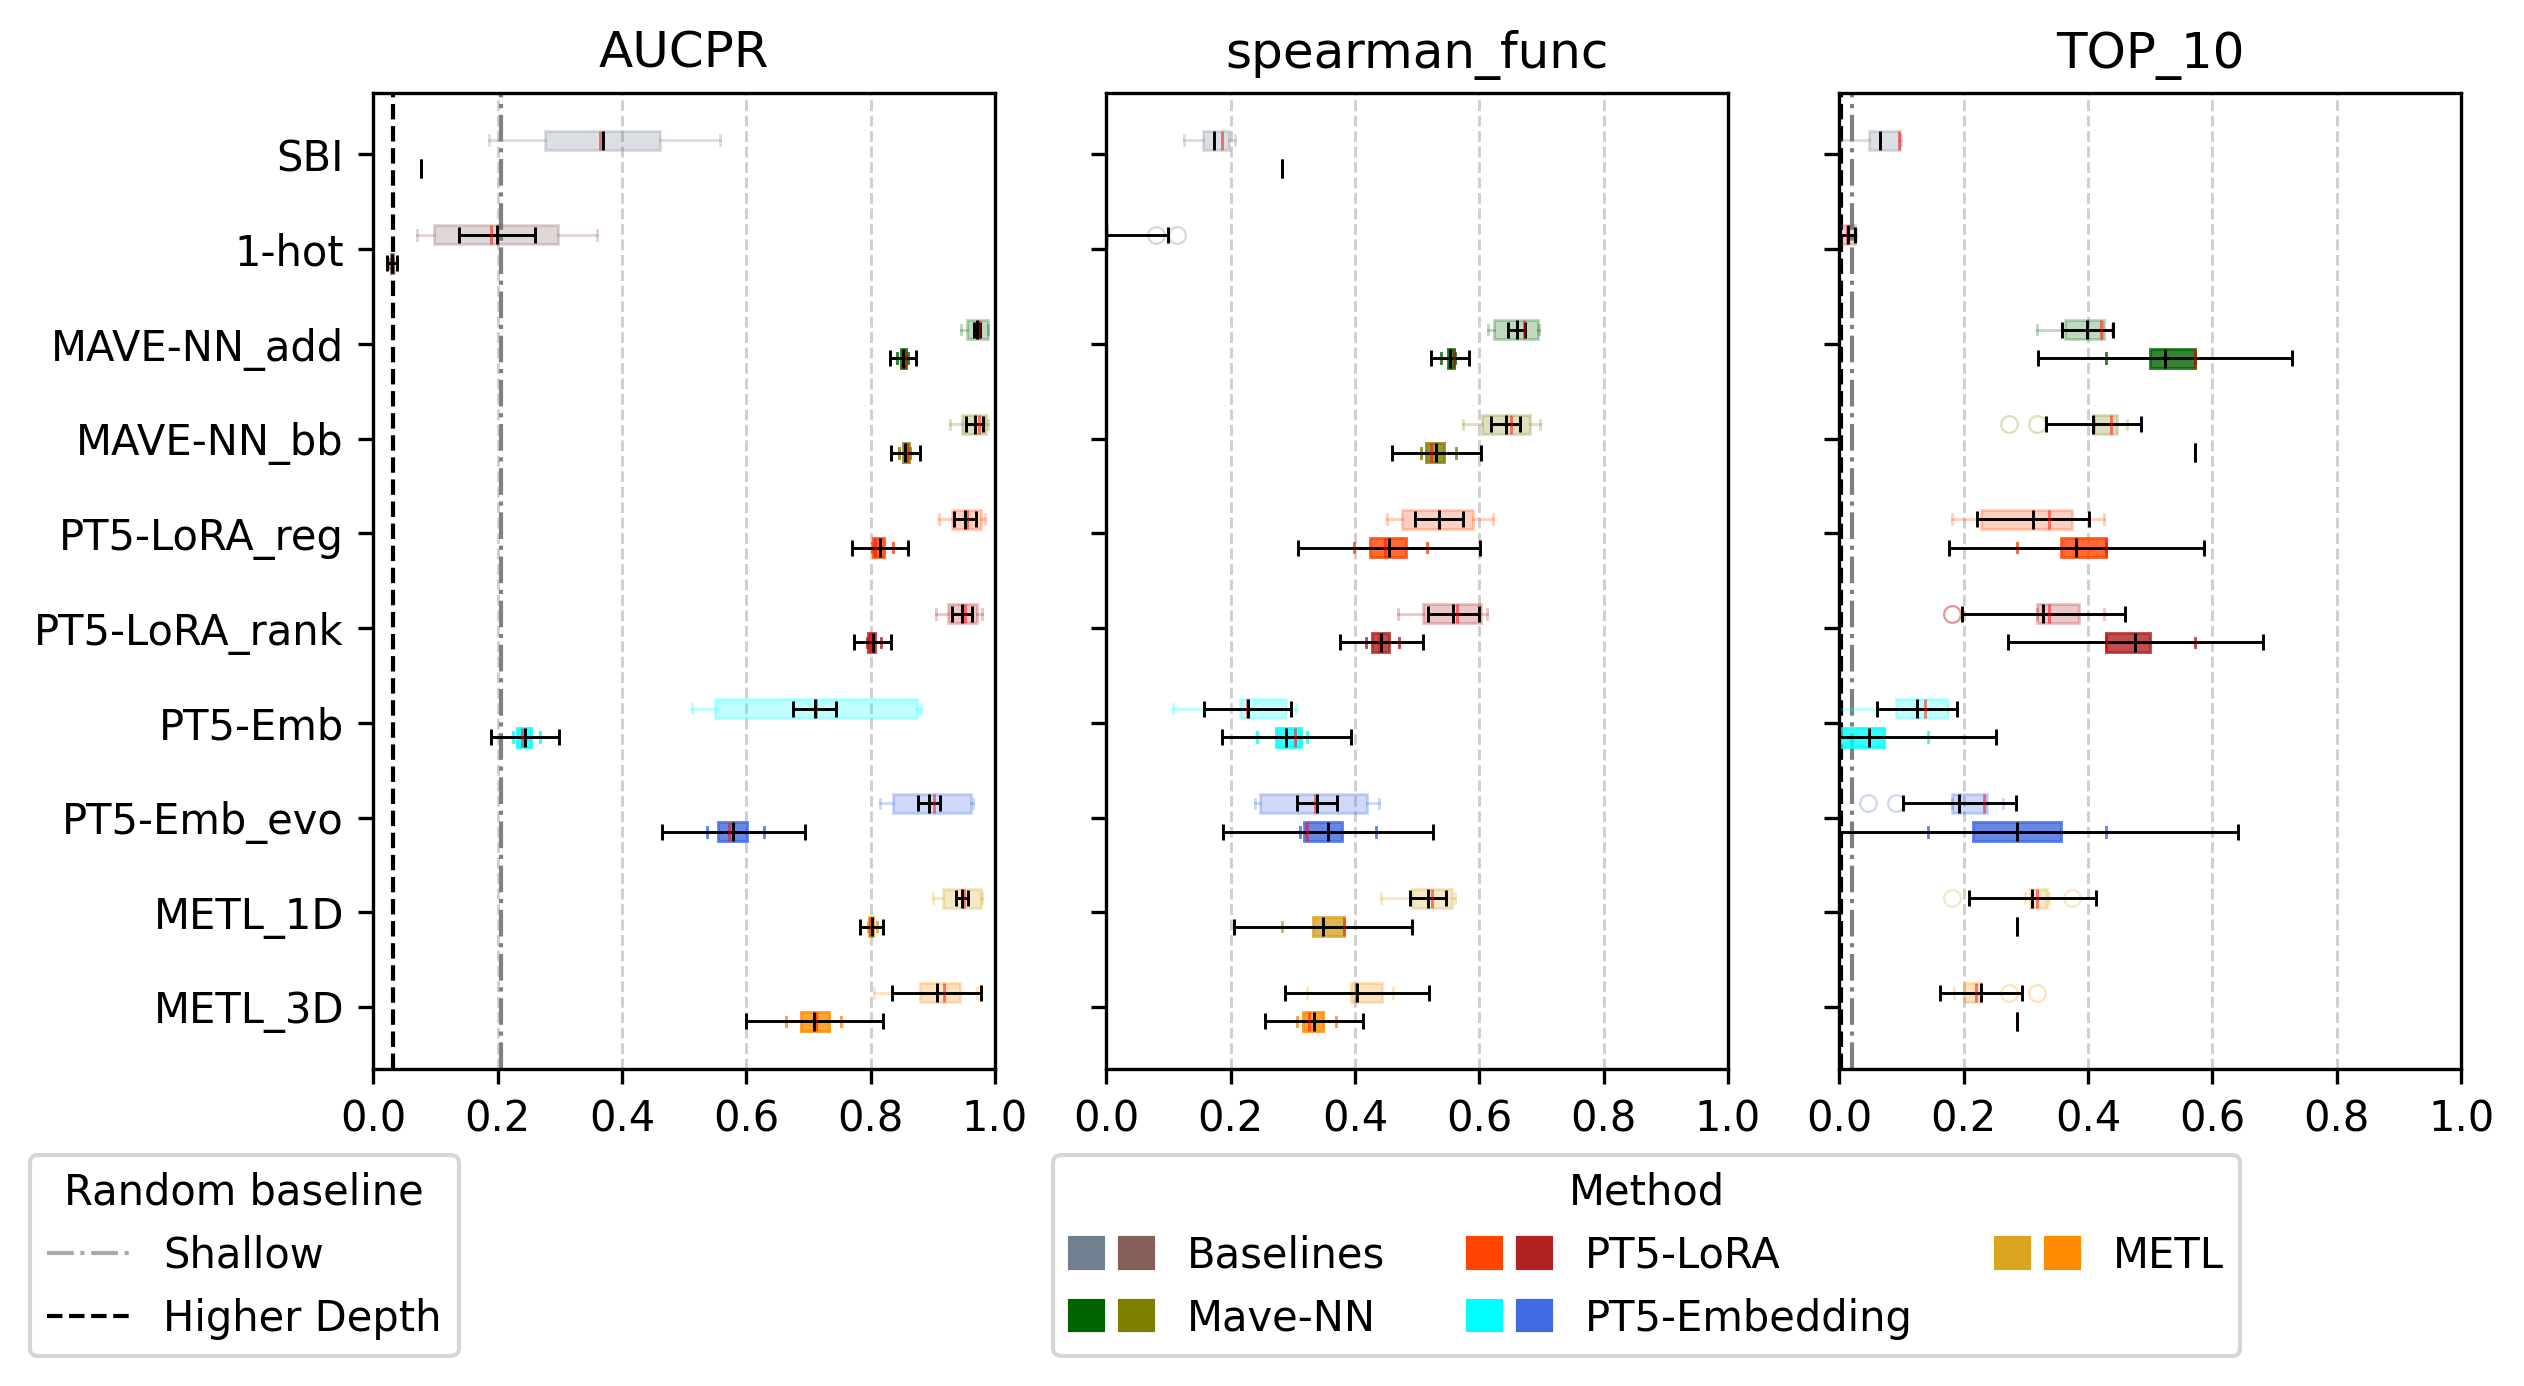

HIS7_YEAST_Pokusaeva_2019


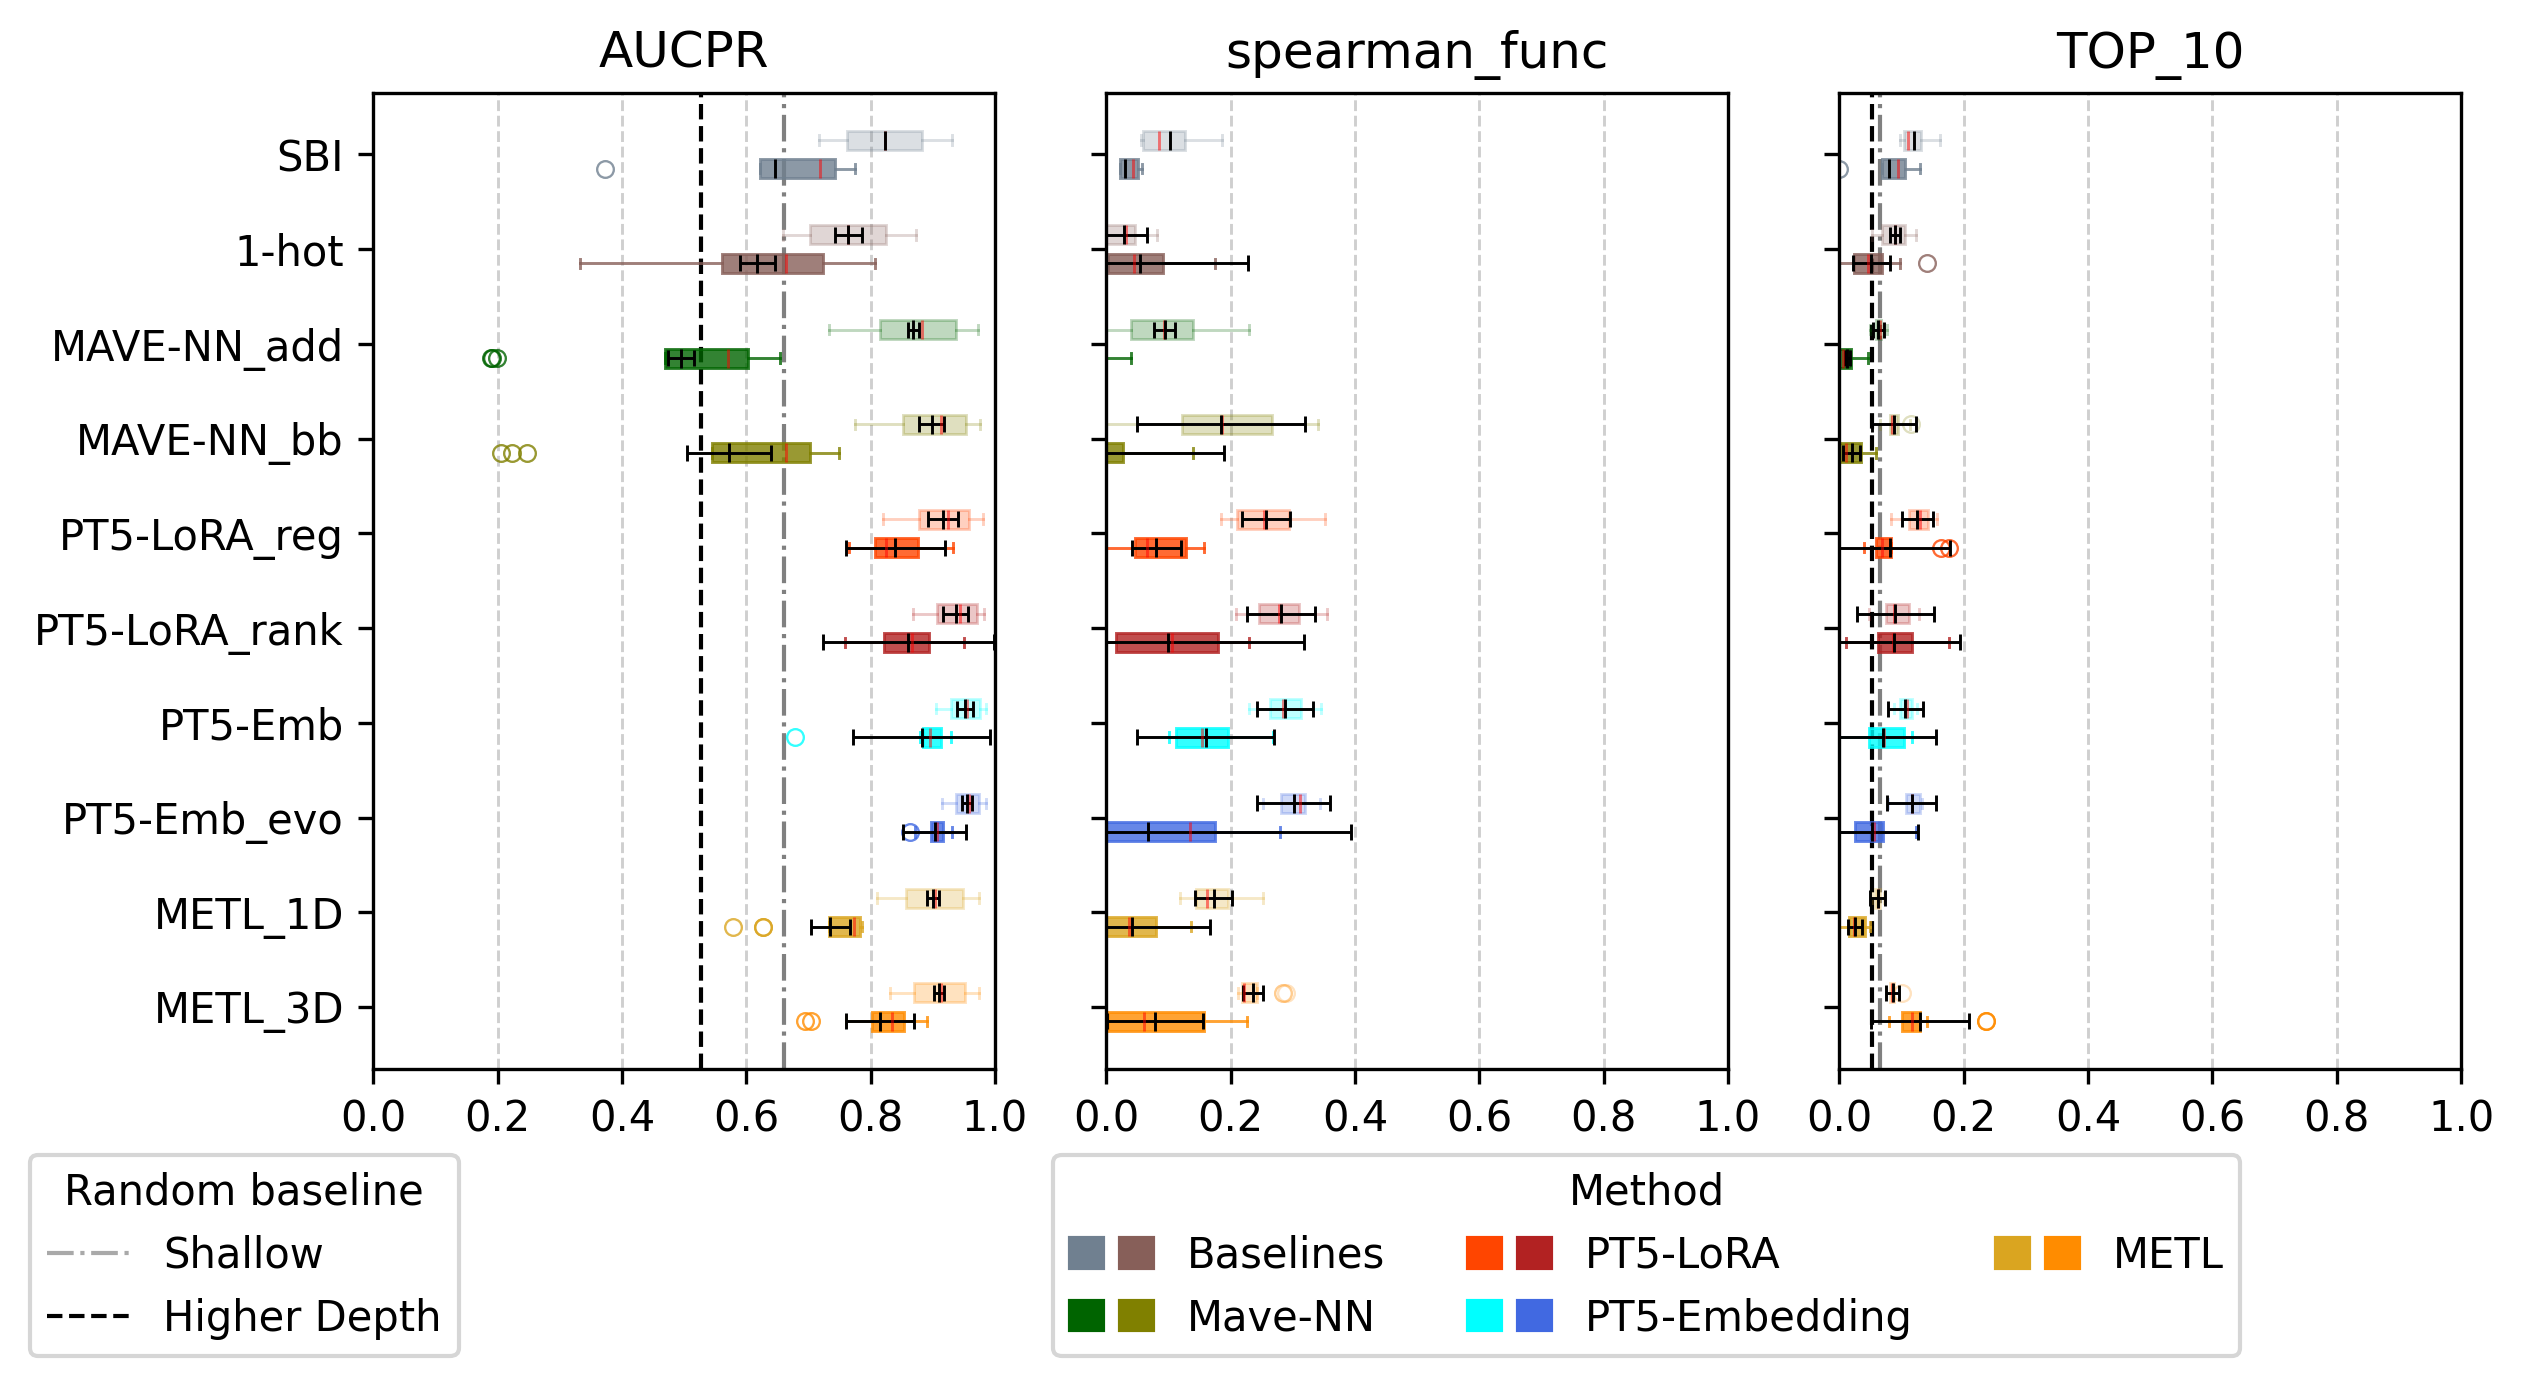

PHOT_CHLRE_Chen_2023


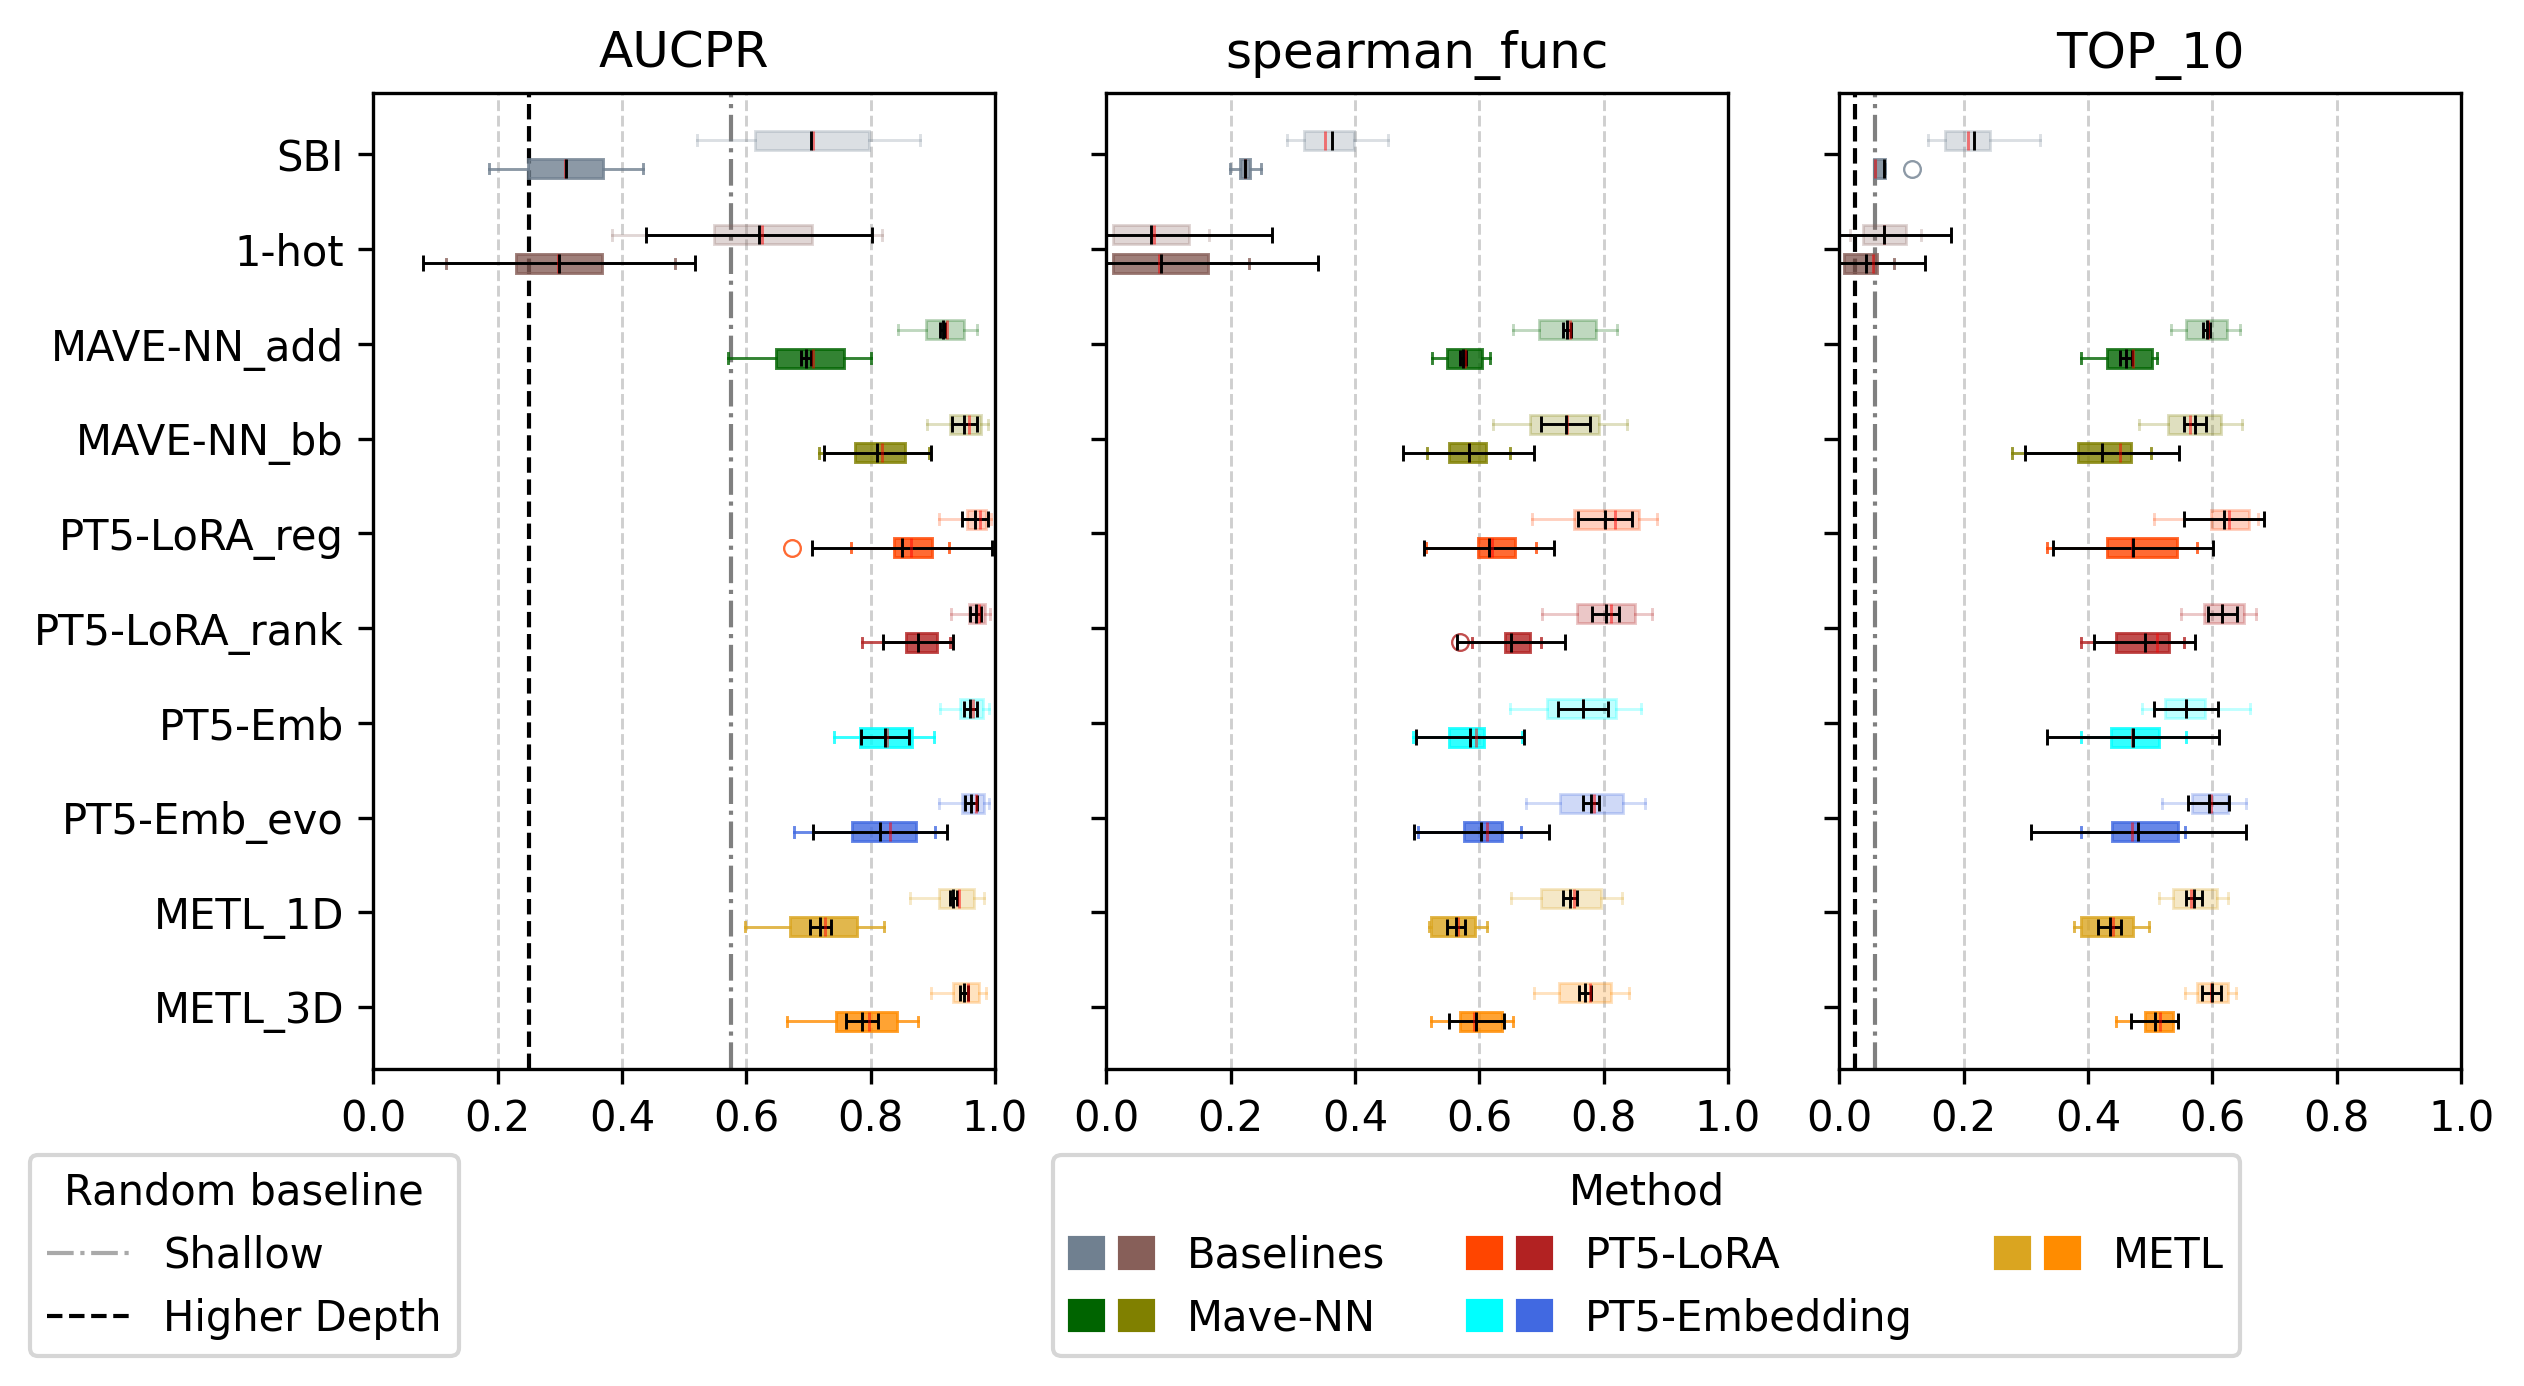

In [12]:
for f in files:
    print(f)
    plot_multi_model_multi_metric_DeePEn(methods = models, 
                                     datas = [f], 
                                     metric = ["AUCPR" , "spearman_func","TOP_10"], 
                                     main = True)

### Fig. S6

In [13]:
# Load the embedding from the .npy file
combined_array = np.load('./results/SOM/Embeddings_Fig_S6/embeddings.npy')

# Load the labels for the 1000 sequences
labels = np.load('./results/SOM/Embeddings_Fig_S6/labels.npy')

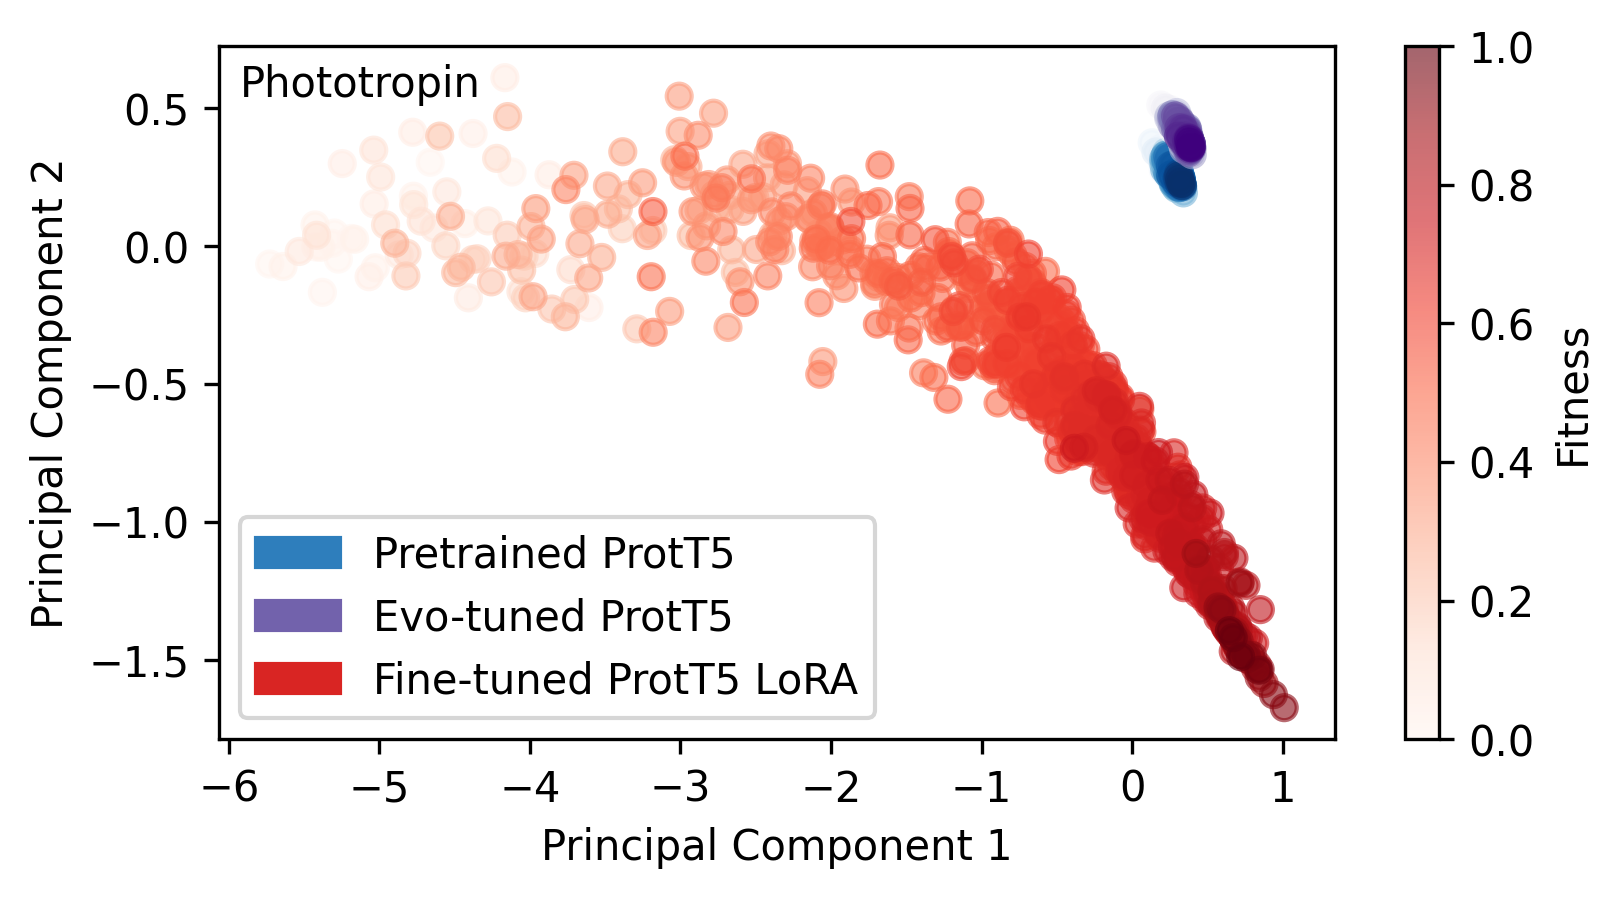

In [14]:
# # Perform PCA to reduce dimensions from 1024 to 2
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_array)

# Split the result back into parts for coloring purposes
# holds the same 1000 sequences/embeddings for each of 
# Pretrained ProtT5, Evo-tuned ProtT5 and Fine-tuned ProtT5 LoRA
pca_array1 = pca_result[0:1000]    # Pretrained ProtT5
pca_array2 = pca_result[1000:2000] # Evo-tuned ProtT5
pca_array3 = pca_result[2000:3000] # Fine-tuned ProtT5 LoRA

# Normalize these labels between 0 and 1 for color mapping
normalized_values = (labels - labels.min()) / (labels.max() - labels.min())

# Choose the colormap for shades of orange
cmap = plt.cm.Reds
cmap_e_1 = plt.cm.Purples
cmap_e_2  = plt.cm.Blues

# Plotting the PCA results
plt.figure(figsize=(6, 3),dpi=300)
plt.scatter(pca_array1[:, 0], pca_array1[:, 1], c=normalized_values, cmap=cmap_e_2, alpha=0.6)
plt.scatter(pca_array2[:, 0], pca_array2[:, 1], c=normalized_values, cmap=cmap_e_1, alpha=0.6)
plt.scatter(pca_array3[:, 0], pca_array3[:, 1], c=normalized_values, cmap=cmap, alpha=0.6)

# Create proxy artists for the legend
proxy_artist1 = mpatches.Patch(color=cmap_e_2(0.7), label='Pretrained ProtT5')
proxy_artist2 = mpatches.Patch(color=cmap_e_1(0.7), label='Evo-tuned ProtT5')
proxy_artist3 = mpatches.Patch(color=cmap(0.7), label='Fine-tuned ProtT5 LoRA')

# plt.title("Embeddings PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(handles=[proxy_artist1, proxy_artist2, proxy_artist3]) 
plt.colorbar(label='Fitness')

plt.text(0.235, 0.975, 'Phototropin', ha='right', va='top', transform=plt.gca().transAxes)

plt.show()

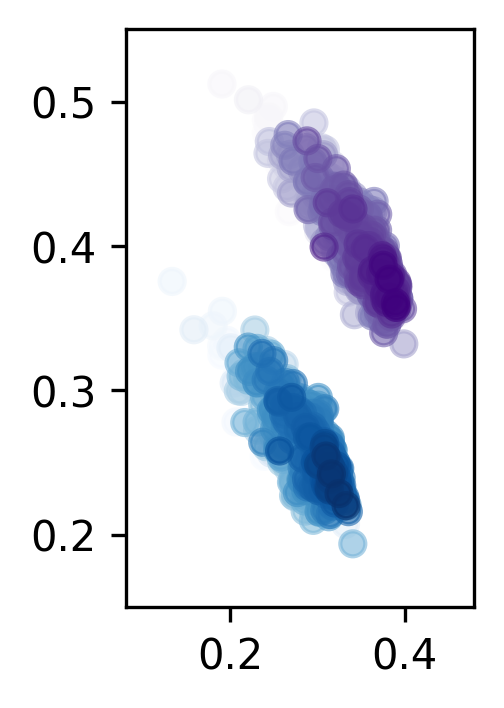

In [15]:
# Plotting the PCA results without fine-tuned
plt.figure(figsize=(1.5, 2.5),dpi=300)
plt.scatter(pca_array1[:, 0], pca_array1[:, 1], c=normalized_values, cmap=cmap_e_2, alpha=0.6)
plt.scatter(pca_array2[:, 0], pca_array2[:, 1], c=normalized_values, cmap=cmap_e_1, alpha=0.6)

# Create proxy artists for the legend
proxy_artist1 = mpatches.Patch(color=cmap_e_2(0.5), label='Pretrained ProtT5')
proxy_artist2 = mpatches.Patch(color=cmap_e_1(0.5), label='Continued Pretraining on CHLRE MSA')

plt.ylim(0.15, 0.55)
plt.yticks(np.arange(0.2, 0.6, 0.1))
plt.xlim(0.08, 0.48) 

plt.show()

### Figure S7

In [16]:
models = ['SBI',
         '1-hot',
         'MAVE-NN_add',
         'MAVE-NN_bb',
         'PT5-LoRA_reg',
         'PT5-LoRA_rank',
         'PT5-Emb',
         'PT5-Emb_evo',
         'METL_1D',
         'METL_3D']

In [17]:
df_metric = table_multi_model_multi_metric_DeePEn(models,files,["AUCPR", "spearman_func", "TOP_10", "NDCG@10"], aggregate = False)

In [18]:
res = pd.DataFrame(columns=["method","depth","seed","AUCPR", "spearman_func", "TOP_10", "NDCG@10"]) 

for k, met in enumerate(["AUCPR", "spearman_func", "TOP_10", "NDCG@10"]):

    dfs =  df_metric[k][0]                                             
    dfs_tail =  df_metric[k][1]

    for idx, (df, tail, m) in enumerate(zip(dfs, dfs_tail, models)):

        # Calculate mean for each individual model run (per seed)
        grouped = df.groupby(['data',"Seed"])
        df = grouped['value'].agg(['mean', 'count']).reset_index()
        seeds = df.Seed.unique().tolist()
        
        for s in seeds:
            mean_df = df[df.Seed == s]["mean"].mean()
            new_row = pd.DataFrame([{'method': m, 'seed': s, 'depth' : "shallow (5-9)", met : str(round(mean_df,3))}])
            res = pd.concat([res,new_row], ignore_index=True)
            
        grouped = tail.groupby(['data',"Seed"])
        tail = grouped['value'].agg(['mean', 'count']).reset_index()
        seeds = tail.Seed.unique().tolist()
        
        for s in seeds:
            mean_tail = tail[tail.Seed == s]["mean"].mean()
            new_row = pd.DataFrame([{'method': m, 'seed': s, 'depth' : "higher depth (10+)", met : str(round(mean_tail,3))}])
            res = pd.concat([res,new_row], ignore_index=True)

# Group by the identifier columns and apply the first non-null aggregation
res = res.groupby(['method', 'depth', "seed"], as_index=False).first()

# Convert the 'method' column to a categorical type with the specified order
res['method'] = pd.Categorical(res['method'], categories=models, ordered=True)

# Sort the DataFrame by the 'method' column
res = res.sort_values(by=['method', "depth"], ascending=[True, False]).reset_index(drop=True)
res.columns = ["method", "depth", "seed", 'AUCPR', 'Spearman', 'Top10%', 'NDCG@10%']
res

,method,depth,seed,AUCPR,Spearman,Top10%,NDCG@10%
0,SBI,shallow (5-9),1,0.629,0.206,0.138,0.569
1,SBI,higher depth (10+),1,0.301,0.14,0.038,0.276
2,1-hot,shallow (5-9),1,0.515,0.002,0.047,0.37
3,1-hot,shallow (5-9),2,0.531,0.052,0.071,0.441
4,1-hot,shallow (5-9),3,0.502,-0.011,0.043,0.345
5,1-hot,higher depth (10+),1,0.264,-0.002,0.023,0.167
6,1-hot,higher depth (10+),2,0.284,0.054,0.034,0.186
7,1-hot,higher depth (10+),3,0.249,-0.007,0.013,0.133
8,MAVE-NN_add,shallow (5-9),1,0.882,0.439,0.302,0.863
9,MAVE-NN_add,shallow (5-9),2,0.882,0.444,0.301,0.865


#### Spearman Correlation

In [19]:
shallow = res[res.depth == "shallow (5-9)"][['AUCPR', 'Spearman', 'Top10%', 'NDCG@10%']].corr(method='spearman')
shallow

,AUCPR,Spearman,Top10%,NDCG@10%
AUCPR,1.000000,0.836942,0.733078,0.932329
Spearman,0.836942,1.000000,0.949849,0.778630
Top10%,0.733078,0.949849,1.000000,0.691644
NDCG@10%,0.932329,0.778630,0.691644,1.000000


In [20]:
high_depth = res[res.depth == "higher depth (10+)"][['AUCPR', 'Spearman', 'Top10%', 'NDCG@10%']].corr(method='spearman')
high_depth

,AUCPR,Spearman,Top10%,NDCG@10%
AUCPR,1.000000,0.778478,0.661922,0.874504
Spearman,0.778478,1.000000,0.612161,0.659455
Top10%,0.661922,0.612161,1.000000,0.748665
NDCG@10%,0.874504,0.659455,0.748665,1.000000


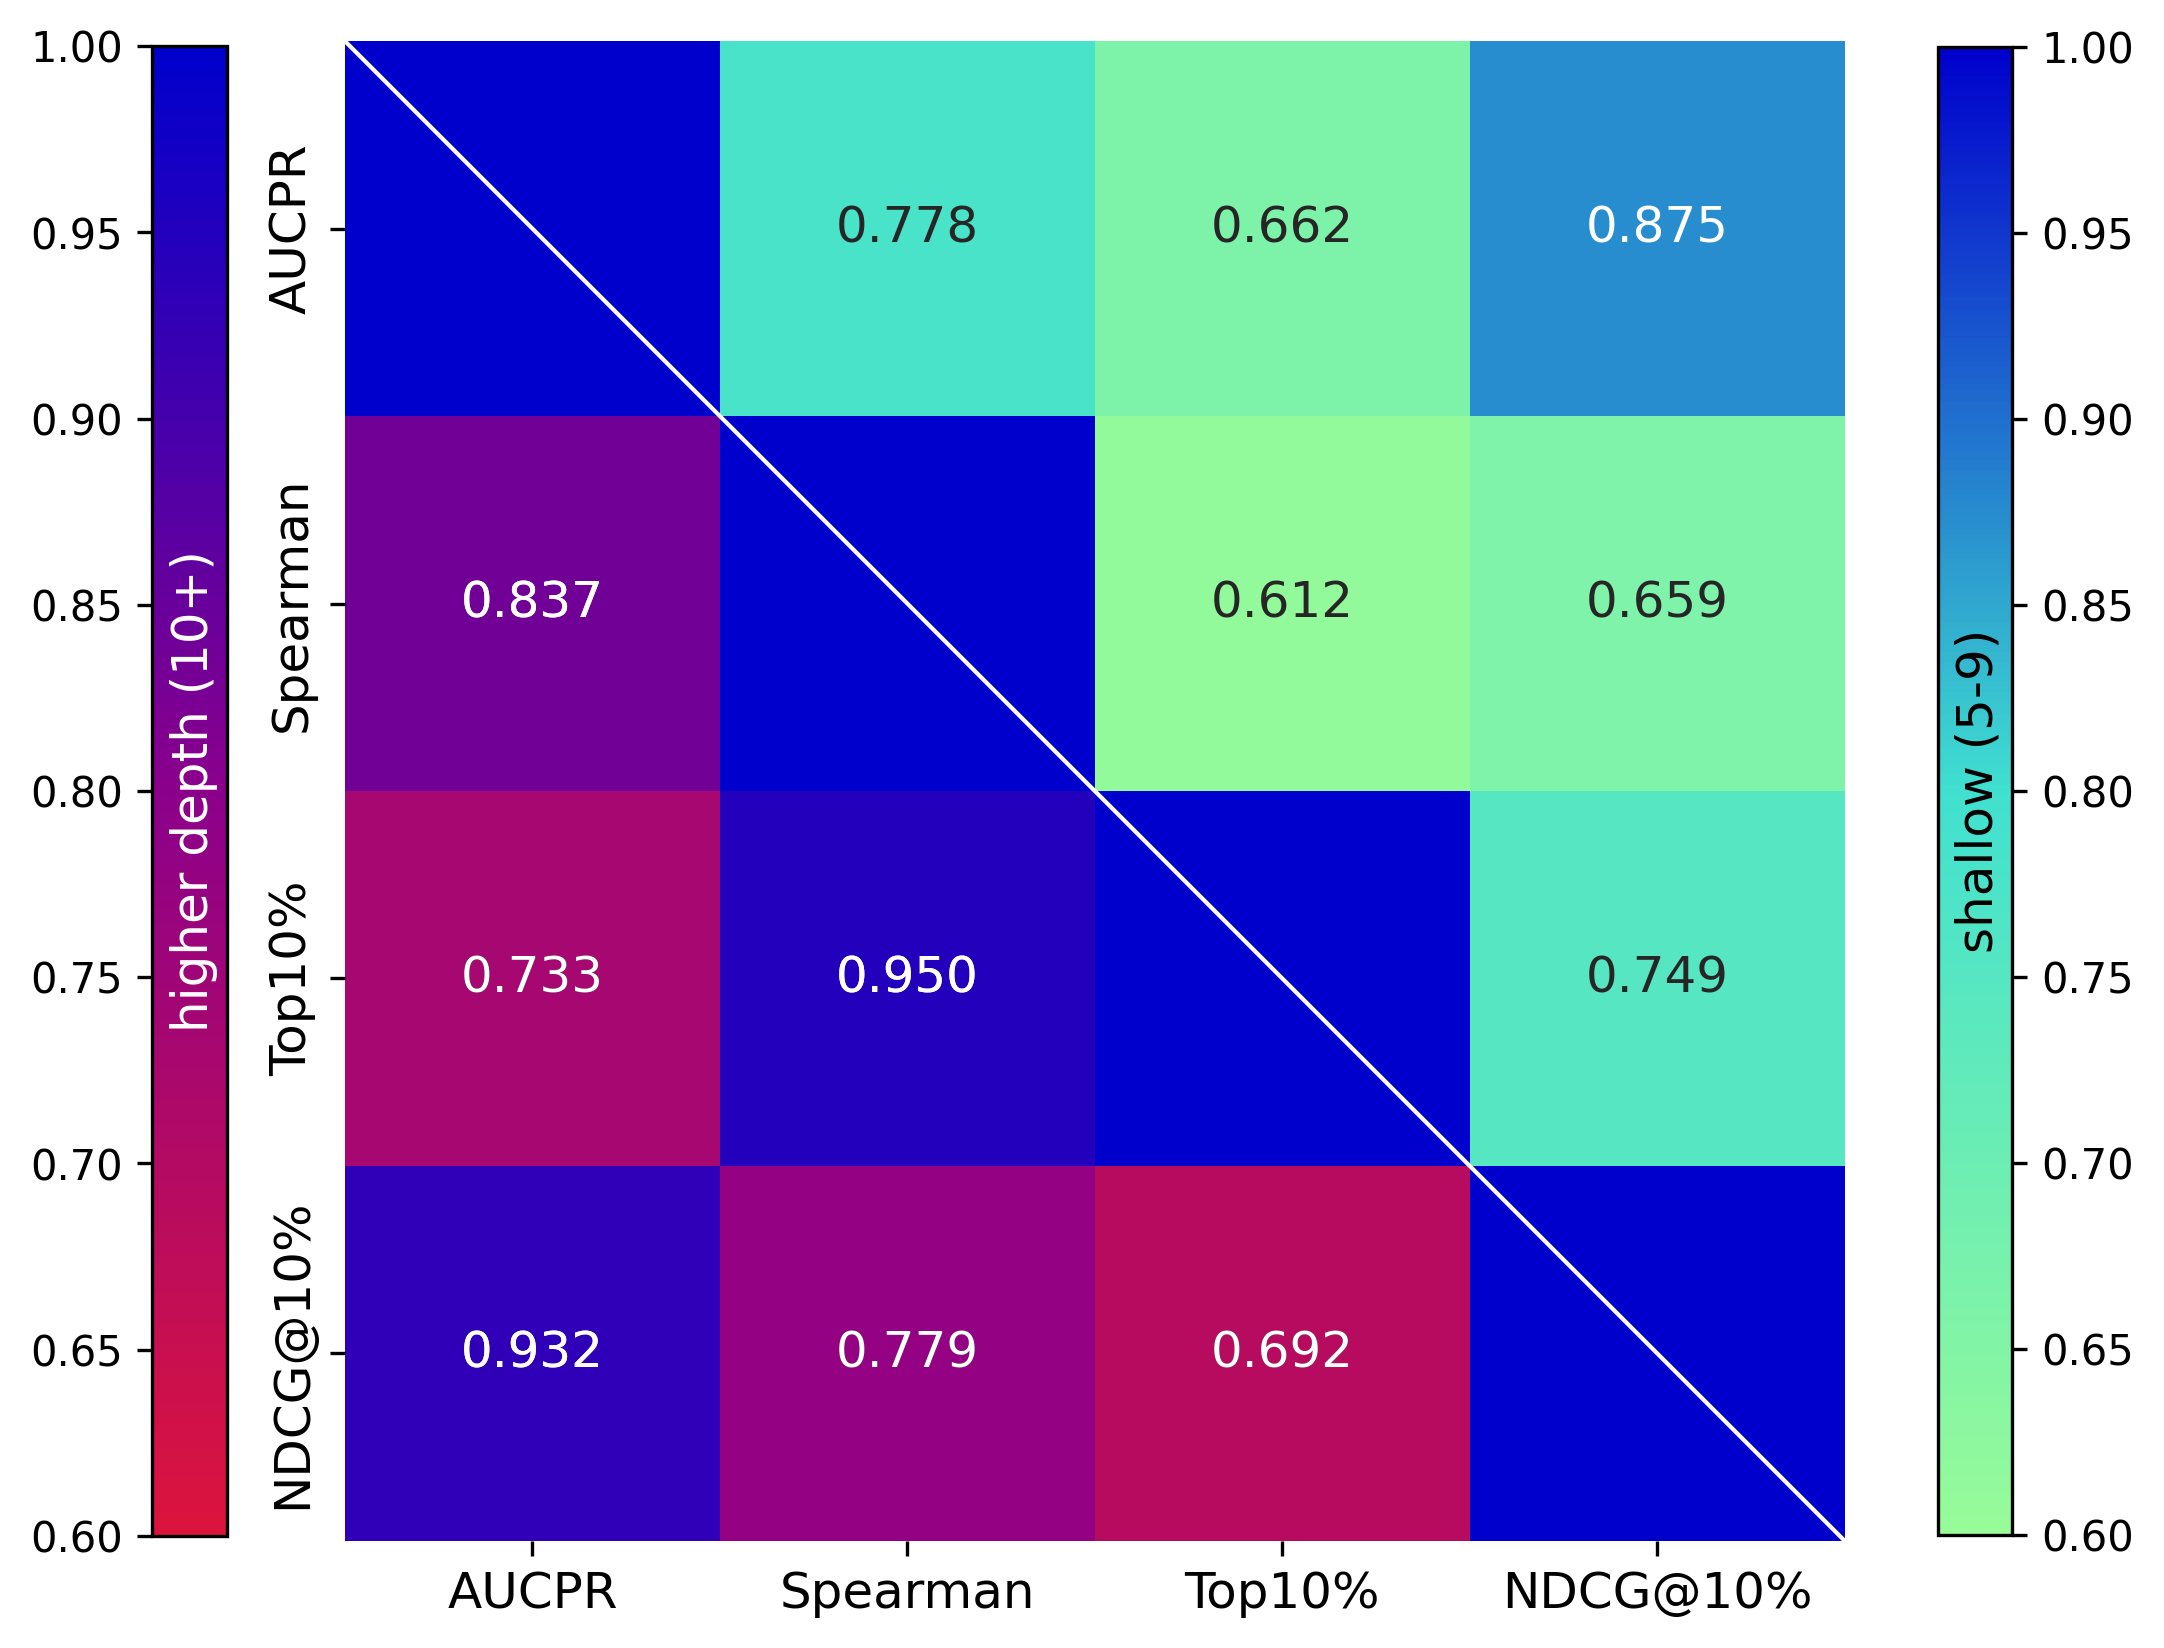

In [21]:
from matplotlib.colors import Normalize, LinearSegmentedColormap

np.random.seed(42)

cols = ['AUCPR', 'Spearman', 'Top10%', 'NDCG@10%']
n = len(cols)


# Create combined matrix
combined = np.zeros((n, n))

# Fill the matrix: lower left with shallow values, upper right with high_depth values
for i in range(n):
    for j in range(n):
        if i > j:  # Lower triangle (shallow)
            combined[i, j] = shallow.iloc[i, j]
        elif i < j:  # Upper triangle (high_depth)
            combined[i, j] = high_depth.iloc[i, j]
        else:  # Diagonal
            combined[i, j] = 1.0

# Create a DataFrame with the combined values
combined_df = pd.DataFrame(combined, index=cols, columns=cols)

# Create masks for upper and lower triangles
mask_upper = np.zeros_like(combined, dtype=bool)
mask_lower = np.zeros_like(combined, dtype=bool)
mask_diag = np.zeros_like(combined, dtype=bool)

# Fill masks
for i in range(n):
    for j in range(n):
        if i >= j:  # Lower triangle including diagonal
            mask_upper[i, j] = False
        if i <= j:  # Upper triangle including diagonal
            mask_lower[i, j] = True
        if i == j:  # Upper triangle including diagonal
            mask_upper[i, j] = True
        if i != j:  # Upper triangle including diagonal
            mask_diag[i, j] = True

# Create the figure and axes
plt.figure(figsize=(8, 7), dpi=300)

# Create custom colormaps
shallow_cm = LinearSegmentedColormap.from_list("shallow", ["crimson","darkmagenta", "mediumblue",])
deep_cm = LinearSegmentedColormap.from_list("deep", ["palegreen","turquoise", "mediumblue",])

# Plot the lower triangle (shallow data) with coolwarm colormap
ax1 = sns.heatmap(combined_df, mask=mask_upper, cmap=deep_cm, vmin=0.6, vmax=1,
                  annot=True, fmt='.3f', cbar=False, square=True, annot_kws={"size": 12})
ax1 = sns.heatmap(combined_df, mask=mask_diag, cmap=deep_cm, vmin=0.6, vmax=1,
                  annot=False, fmt='.3f', cbar=False, square=True, annot_kws={"size": 12})
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=12)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=12)
# Plot the upper triangle (high_depth data) with autumn colormap
ax2 = sns.heatmap(combined_df, mask=mask_lower, cmap=shallow_cm, vmin=0.6, vmax=1,
                  annot=True, fmt='.3f', cbar=False, square=True, annot_kws={"size": 12})

# for x in range(mask_upper.shape[0]):
#     ax1.text(x+0.7, x+0.3, '1.000', ha='center', va='center', fontsize=11, color = "white")
#     # Place bottom-left label
#     ax1.text(x+0.3, x+0.7, '1.000', ha='center', va='center', fontsize=11, color = "white")
ax1.plot([0, mask_upper.shape[0]], [0, mask_upper.shape[0]], color='white', lw=1)

from matplotlib.cm import ScalarMappable
norm = Normalize(vmin=0.6, vmax=1)
sm1 = ScalarMappable(norm=norm, cmap=deep_cm)
sm2 = ScalarMappable(norm=norm, cmap=shallow_cm)
cbar_s = plt.colorbar(sm1, ax=ax1, location='right', pad=0.05, fraction= 0.04, label='shallow (5-9)')
cbar_s.set_label('shallow (5-9)', labelpad=-43, fontsize=12)

cbar_d =plt.colorbar(sm2, ax=ax2, location='left', pad=0.07, fraction= 0.044, label='higher depth (10+)')
cbar_d.set_label('higher depth (10+)', labelpad=-45, fontsize=12, color = "white")
# plt.tight_layout()

# Display the plot
plt.show()

#### Pearson Correlation

Pearson Correlation are very high, all around 0.9 or higher.
The reason is that Pearson Correlation is very dependant on outliers. Here the baseline predictors (1-hot and SBI) will be signifcantly worse than the more advanced models for all four metrics, leading to high correlations. 

In [22]:
shallow = res[res.depth == "shallow (5-9)"][['AUCPR', 'Spearman', 'Top10%', 'NDCG@10%']].corr()
shallow

,AUCPR,Spearman,Top10%,NDCG@10%
AUCPR,1.000000,0.986238,0.974008,0.994184
Spearman,0.986238,1.000000,0.991060,0.986860
Top10%,0.974008,0.991060,1.000000,0.971971
NDCG@10%,0.994184,0.986860,0.971971,1.000000


In [23]:
high_depth = res[res.depth == "higher depth (10+)"][['AUCPR', 'Spearman', 'Top10%', 'NDCG@10%']].corr()
high_depth

,AUCPR,Spearman,Top10%,NDCG@10%
AUCPR,1.000000,0.959453,0.904492,0.970008
Spearman,0.959453,1.000000,0.891280,0.934762
Top10%,0.904492,0.891280,1.000000,0.923405
NDCG@10%,0.970008,0.934762,0.923405,1.000000


### Fig. S8

In [24]:
# Function to determine positive vs. negative epistasis
def evaluate_mutations(row, mutation_dict, wt, offset=0):
    mutations = row['mutation_list']
    
    # Check if all mutations are in the dictionary
    if not all(mutation in mutation_dict for mutation in mutations):
        return np.nan  # If any mutation is missing, return NaN
    
    # Calculate the sum of the values for the present mutations
    sum_values = sum((mutation_dict[mutation] - wt) for mutation in mutations) + wt
    
    # Compare the sum to the DMS_score
    if row['DMS_score'] >= sum_values + offset:
        return 1
    elif row['DMS_score'] <= sum_values - offset:
        return -1
    else:
        return 0


def epistatic(file, wt):
    df = pd.read_csv("./data/raw/" + file + "/DMS_raw.csv", low_memory=False) 
    
    if 'log_delta' in df.columns:
        df['DMS_score'] = df['log_delta']


    df = df[df.set!="wt"] 
    print(file)

    # Evaluate mutations captured in training
    df_train = df[df.mutation_depth <= 1].copy()
    mutation_dict = df_train.set_index('mutant')['DMS_score'].to_dict()

    train = df[df.mutation_depth >1 ].copy().reset_index(drop=True)
    train.loc[:,'mutation_list'] = train["mutant"].str.split(':')

    # Apply the evaluation function to each row
    train['all_positive'] = train.apply(evaluate_mutations, axis=1, mutation_dict=mutation_dict, wt = wt, offset = df.DMS_score.std() *0.625)
    train = train.drop(columns=['mutation_list'])

    cutoff = get_cutoff(file)

    train.loc[train['mutation_depth'] >= cutoff, 'mutation_depth'] = cutoff

    return train


In [25]:
def print_epistasis(df, name):

    # Calculate the percentage for each new_column value (-1, 0, 1), grouped by mutation_depth
    percentage_df = df.groupby(['mutation_depth', 'all_positive']).size().unstack(fill_value=0)
    percentage_df = percentage_df.reindex(columns=[-1, 0, 1], fill_value=0)
    percentage_df = percentage_df.div(percentage_df.sum(axis=1), axis=0) * 100
   

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 3),dpi=300)

    # Create stacked bars for new_column
    percentage_df.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=['tab:red', "lightgrey",'tab:blue'])

    # Mapping new_column values to labels for legend
    labels = {1: 'positive', -1: 'negative', 0: "weak"}
    handles, _ = ax.get_legend_handles_labels()

    ax.legend(handles=handles, labels=[labels.get(int(label)) for label in percentage_df.columns],  loc='upper left', bbox_to_anchor=(1.0, 1.0), ncol=len(percentage_df.columns), title='Epistasis')

    plt.xlabel('Mutation Depth')
    
    # Use FuncFormatter to add a percentage sign
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    
    ax.set_ylim(0,100)

    ax.set_xticklabels(list(range(2, df.mutation_depth.max())) + [str(df.mutation_depth.max()) + '+'], rotation = 0)
    
    ax.set_title(name)

    plt.tight_layout()
    plt.show()

In [26]:
# wt for AAV = -0.918193710692946
# wt for GFP = 3.7192121319
# wt for YEAST = 1.0
# wt for CHLRE = 0 (using log_delta column instead of DMS_score)
wts = [-0.918193710692946,3.7192121319,1.0,0]
wts

[-0.918193710692946, 3.7192121319, 1.0, 0]

In [27]:
added_names = ["AAV Capsid", "GFP", "Dehydratase", "Phototropin"]

CAPSD_AAV2S_Sinai_2021
0 nan rows, which is 0.0 %


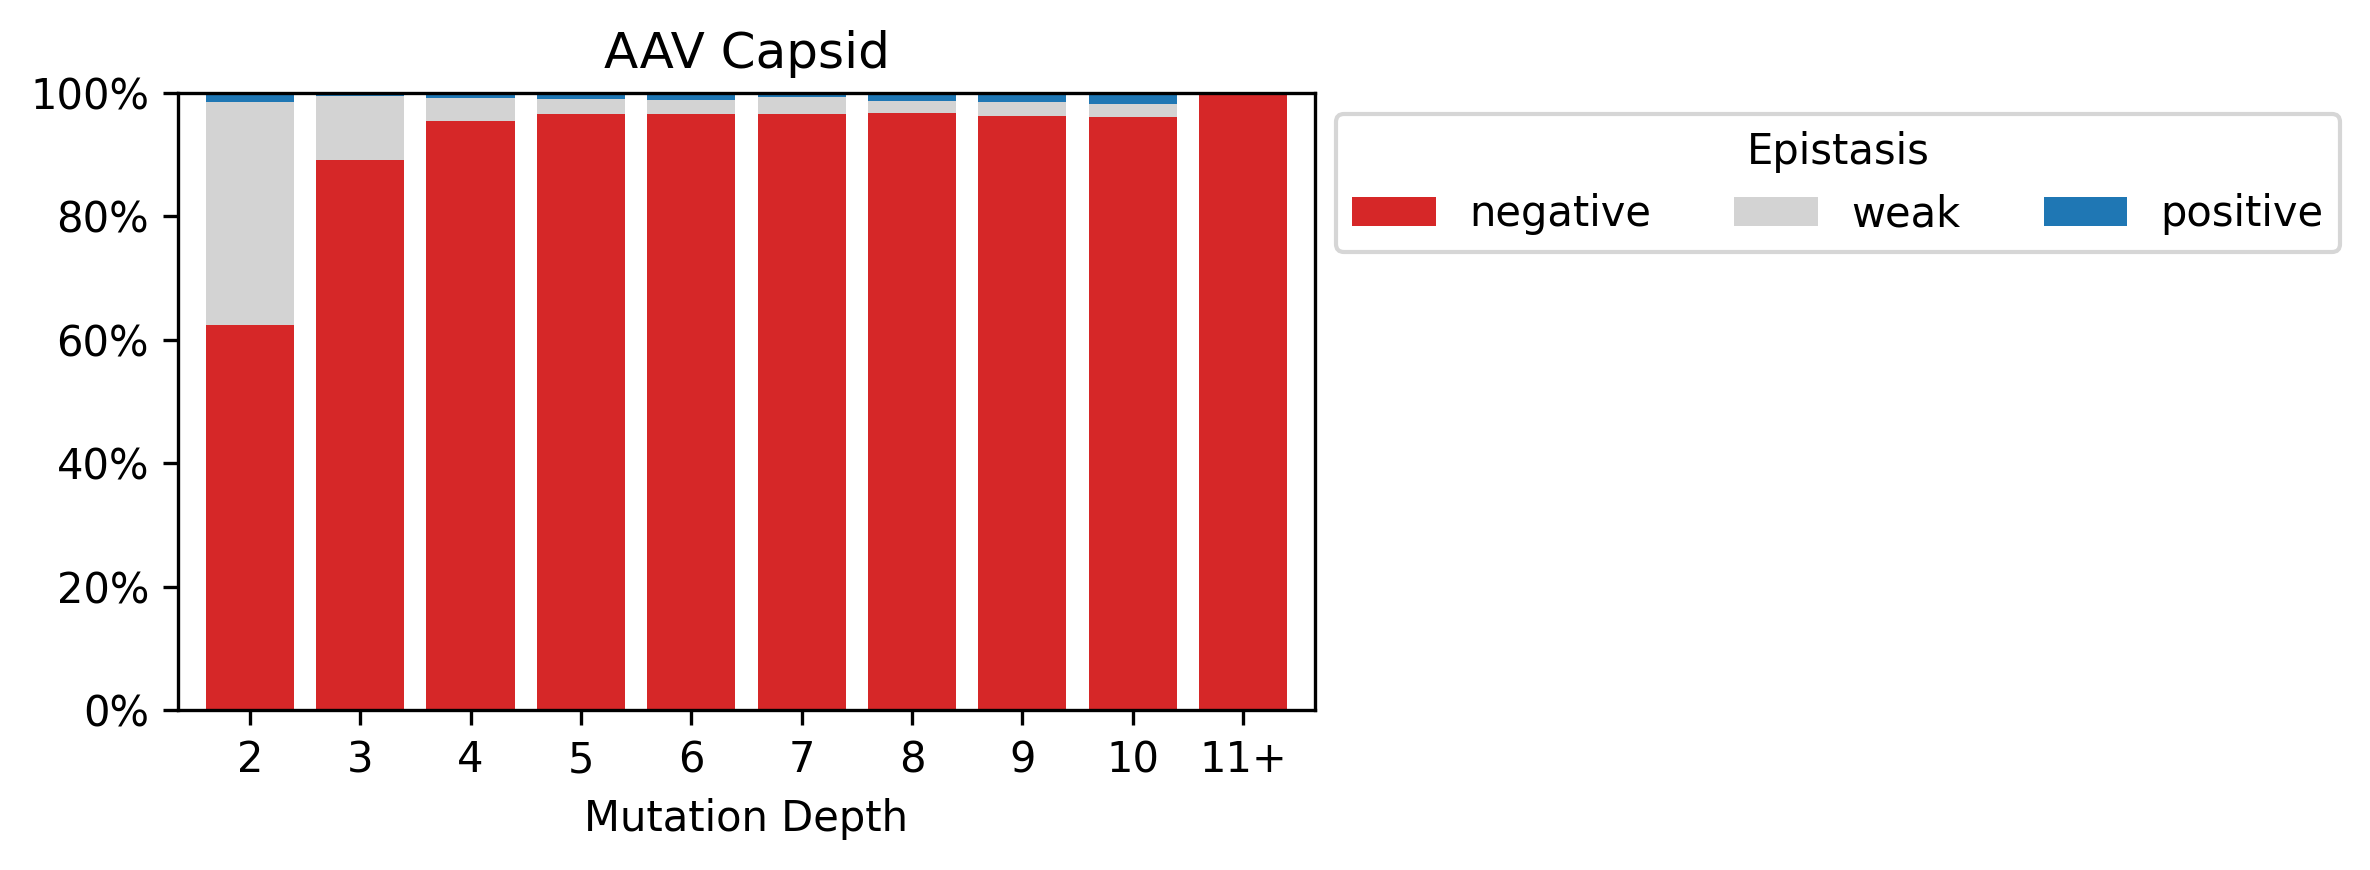

GFP_AEQVI_Sarkisyan_2016
7959 nan rows, which is 15.7 %


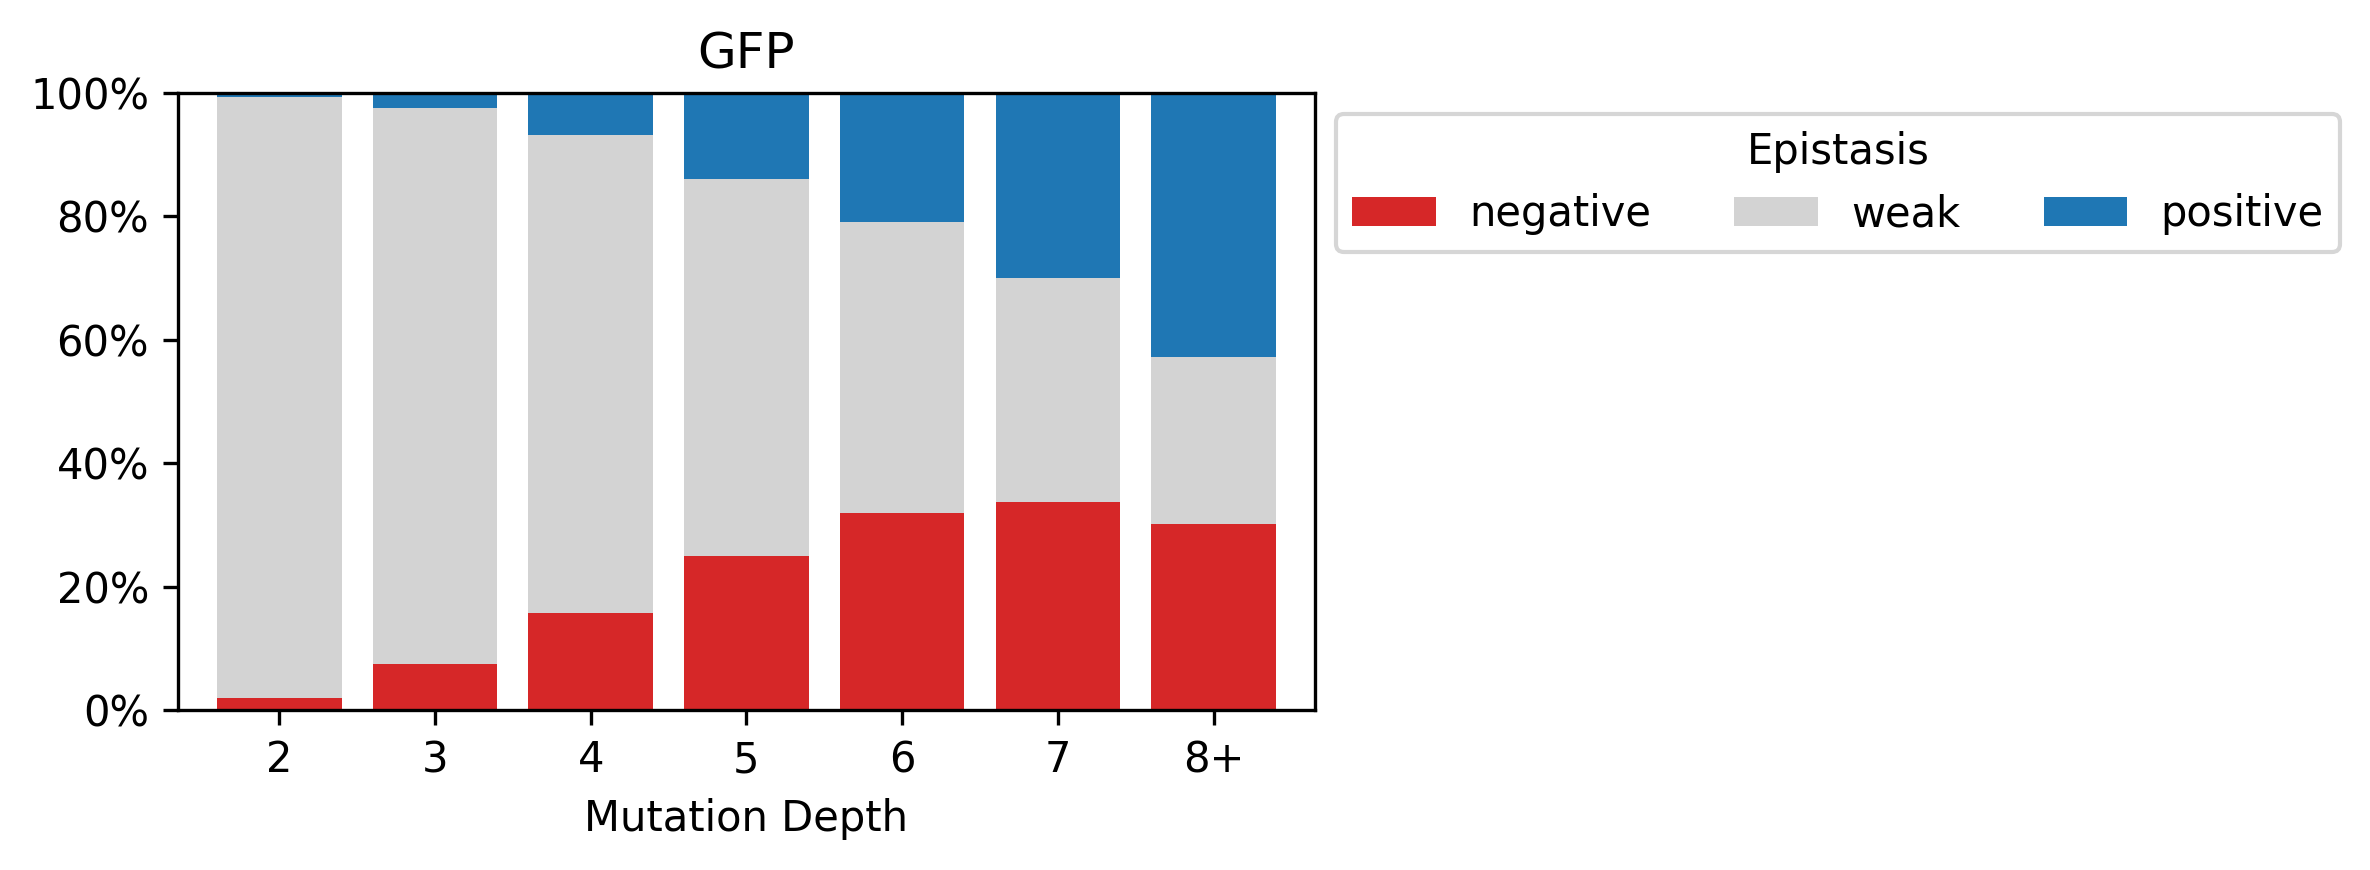

HIS7_YEAST_Pokusaeva_2019
241355 nan rows, which is 48.7 %


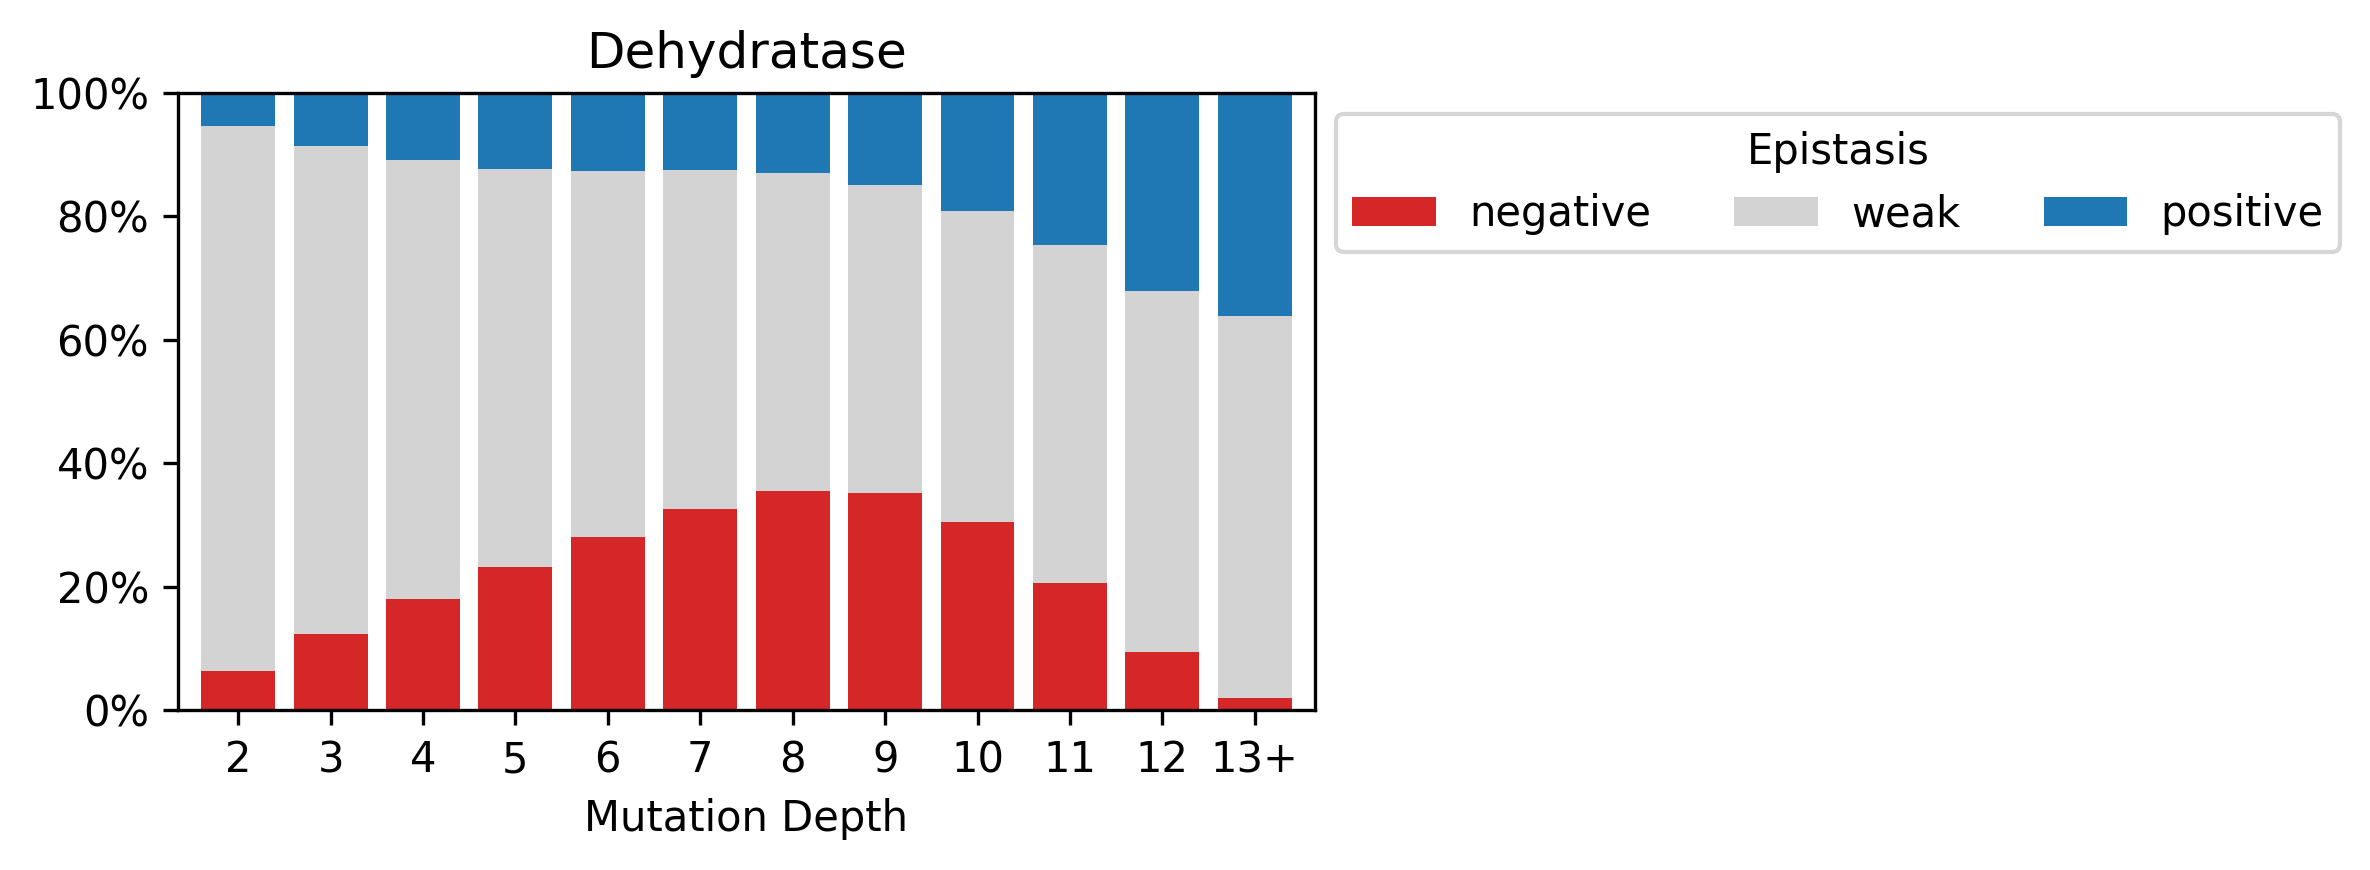

PHOT_CHLRE_Chen_2023
0 nan rows, which is 0.0 %


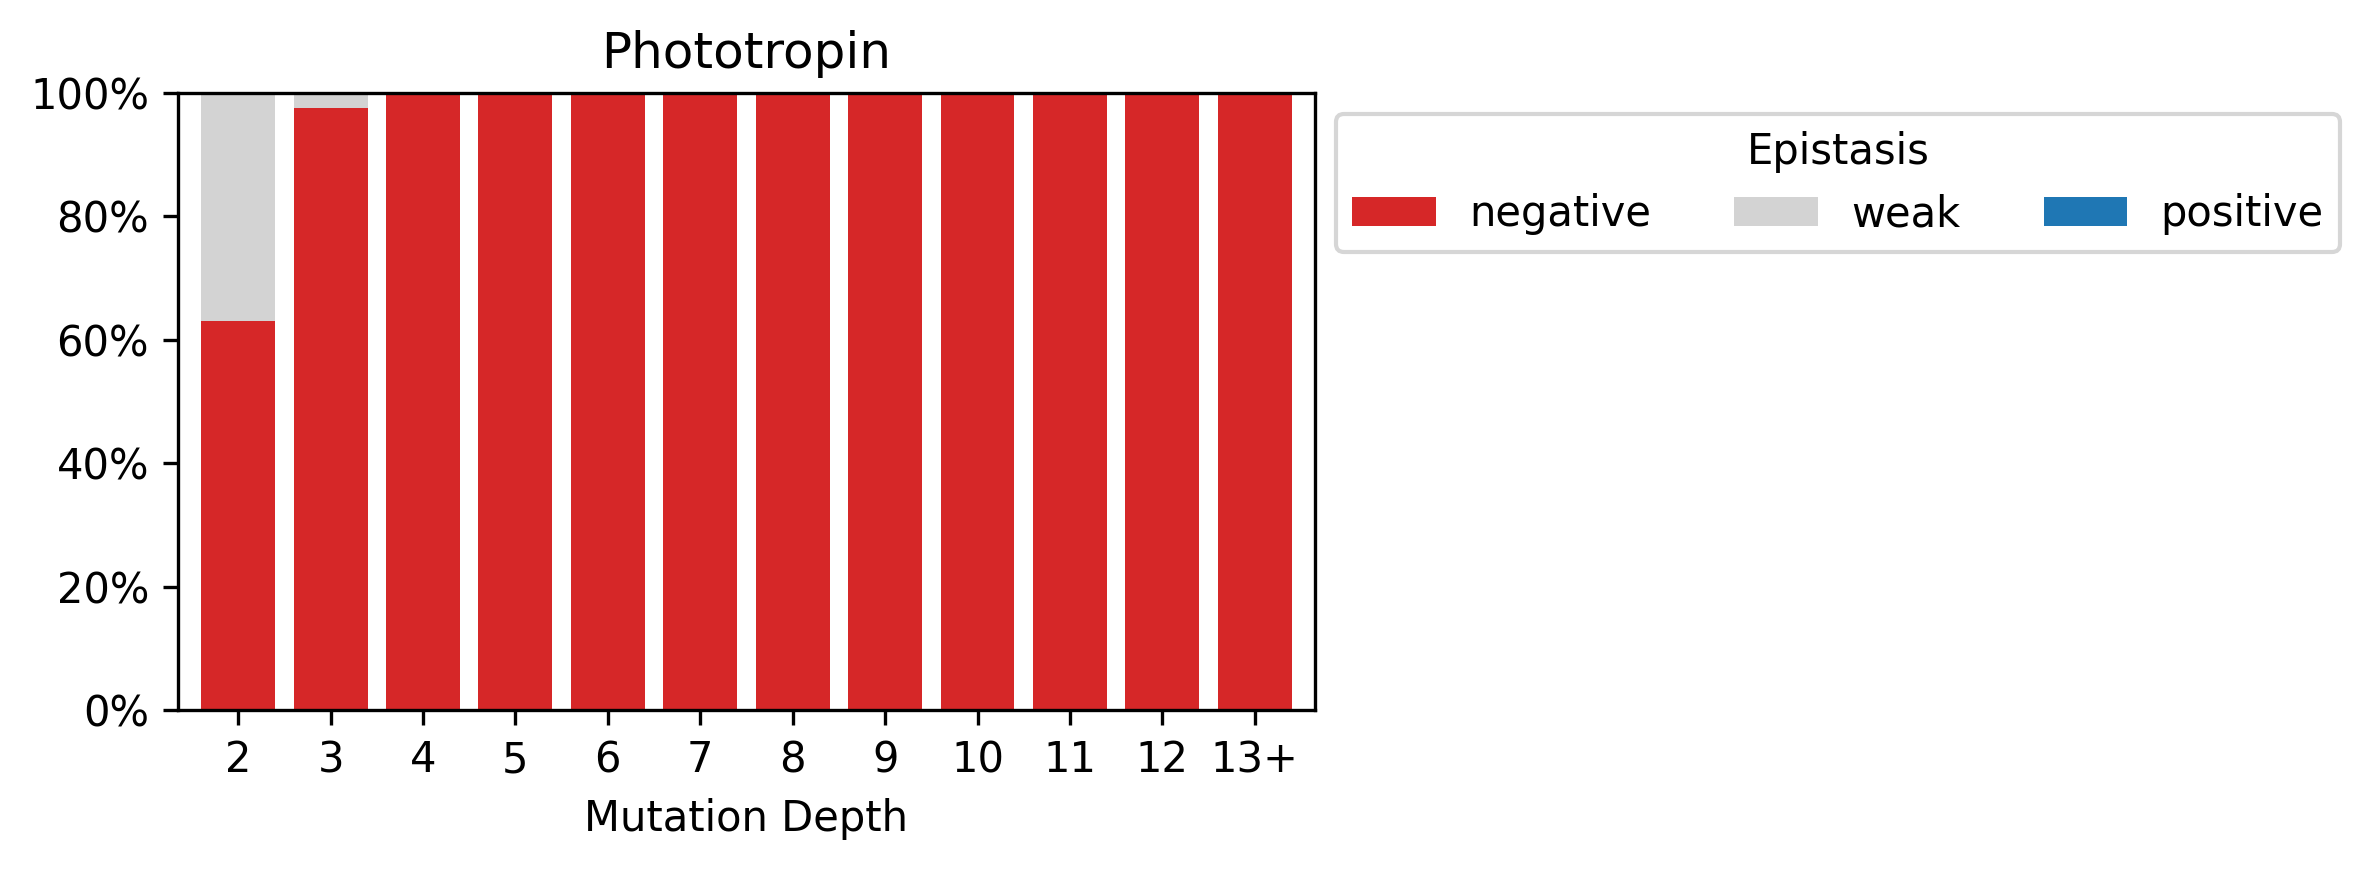

In [28]:
#all data
for f, wt, n in zip(files,wts, added_names):
    
    df = epistatic(f, wt)
    
    #number of rows where not all singletons are available
    print(len(df[df.all_positive.isna()]), "nan rows, which is", round(len(df[df.all_positive.isna()])/len(df)*100,1),"%")
    
    print_epistasis(df,n)

### Fig. S9

In [29]:
#create dfs
models_select = ['PT5-LoRA_rank',
                 'MAVE-NN_bb',         
         'METL_3D']

data= files

# Create an empty DataFrame with specified columns and index
df_sampling = pd.DataFrame(columns=["sample\ncomplete set"] + models_select, index=data)
# Create an empty DataFrame with specified columns and index
df_precision = pd.DataFrame(columns=["sample\ncomplete set"] + models_select, index=data)

# Create an empty DataFrame with specified columns and index
df_sampling_top10p = pd.DataFrame(columns=["sample\ncomplete set"] + models_select, index=data)
# Create an empty DataFrame with specified columns and index
df_precision_top10p = pd.DataFrame(columns=["sample\ncomplete set"] + models_select, index=data)

for data_select in data:
    
    # load data
    df_all = pd.DataFrame()

    for i, m in enumerate(models_select):

        if i == 0:
            df_all = load_results(data_select, "./results/main/" + m)
            cols_with_seed = [col for col in df_all.columns if 'seed' in col]
            df_all = df_all[[col for col in df_all.columns if col not in cols_with_seed] + cols_with_seed]
            df_all.loc[:, m +'_mean'] = df_all[cols_with_seed].mean(axis=1)
            for c in cols_with_seed:
                df_all.rename(columns={c: m + "_" +c}, inplace=True)
        else:
            df = load_results(data_select, "./results/main/" + m)
            cols_with_seed = [col for col in df.columns if 'seed' in col]
            for c in cols_with_seed: 
                df_all.loc[:, m + "_" +c] = df[c]
            df_all.loc[:, m +'_mean'] = df[cols_with_seed].mean(axis=1)

    # Create overall and a to df
    df_all = df_all[df_all.set=="test"]

    df = df_all.copy() 

    # Find the threshold for the top 10% within DMS_score_bin == 1
    threshold = df.loc[df['DMS_score_bin'] == 1, 'DMS_score'].quantile(0.90)

    # Create the binary column
    # 1 for DMS_score in top 10% of the DMS_score_bin == 1 group
    # 0 otherwise
    df['binary_top10'] = 0
    mask = (df['DMS_score_bin'] == 1) & (df['DMS_score'] >= threshold)
    df.loc[mask, 'binary_top10'] = 1

    # Find all columns containing 'mean' (model predictions)
    mean_columns = [col for col in df.columns if 'mean' in col]

    # number of functional variants
    total_positives = df['DMS_score_bin'].sum()
    total_positives_top10 = df['binary_top10'].sum()
    
    # add baseline
    df_sampling.loc[data_select,"sample\ncomplete set"] = 100.0
    df_precision.loc[data_select,"sample\ncomplete set"] = round((total_positives/len(df))* 100,1) 
    
    df_sampling_top10p.loc[data_select,"sample\ncomplete set"] = 100.0
    df_precision_top10p.loc[data_select,"sample\ncomplete set"] = round((total_positives_top10/len(df))* 100,1) 

    
    # Create sampling table for each prediction column
    for column in mean_columns:

        # get model name
        label = column.rsplit('_', 1)[0]

        # Sort by prediction score (descending)
        sorted_df = df.sort_values(by=column, ascending=False)

        # See how many sequences each model needs to sample to reach 95% recall
        target_tp = 0.95 * total_positives
        cum_tp = sorted_df['DMS_score_bin'].cumsum()
        num_needed = (cum_tp < target_tp).sum() + 1  # +1 because you want to get the last example needed as well
        percent_overall = round((num_needed/len(df))* 100,0) 

        df_sampling.loc[data_select,label] = percent_overall            
        
        df_precision.loc[data_select,label] = round((target_tp/num_needed)* 100,1)
        
        # See how many sequences each model needs to sample to reach 95% recall in the top 10%
        target_tp = 0.95 * total_positives_top10
        cum_tp = sorted_df['binary_top10'].cumsum()
        num_needed = (cum_tp < target_tp).sum() + 1  # +1 because you want to get the last example needed as well
        percent_overall = round((num_needed/len(df))* 100,0) 

        df_sampling_top10p.loc[data_select,label] = percent_overall            
        
        df_precision_top10p.loc[data_select,label] = round((target_tp/num_needed)* 100,1)

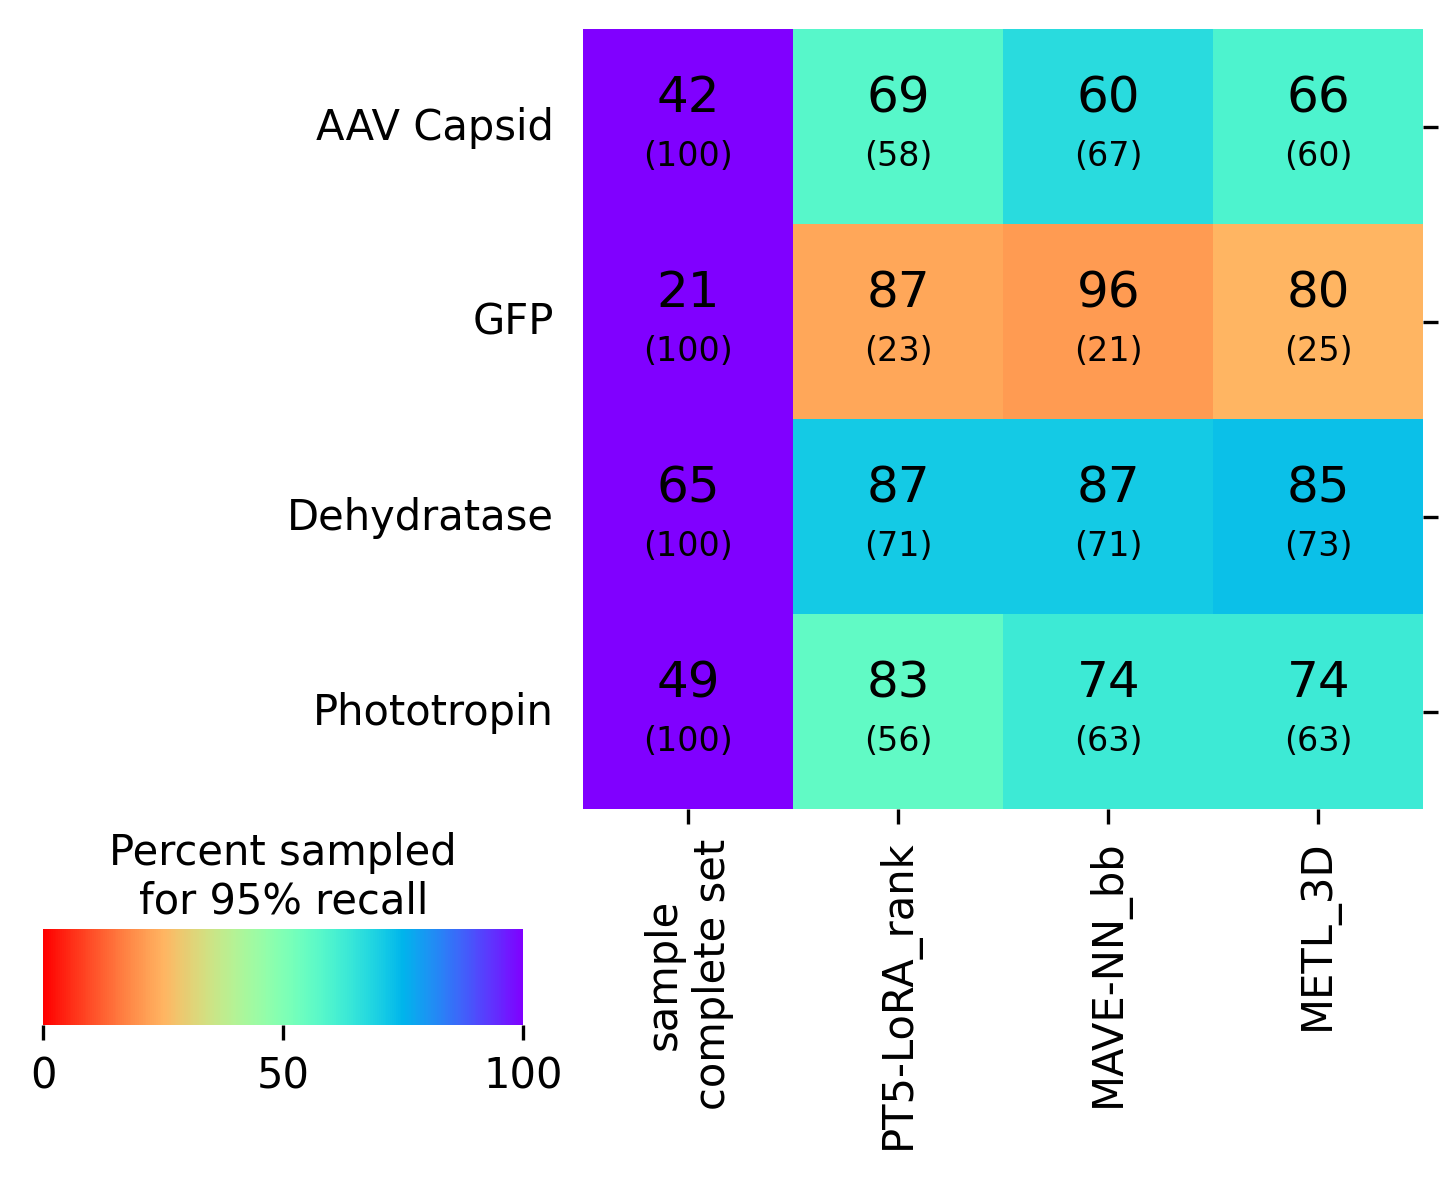

In [30]:
# Panel a
added_names = ["AAV Capsid", "GFP", "Dehydratase", "Phototropin"]

# Ensure numeric values
df_precision_num = df_precision.apply(pd.to_numeric, errors="coerce")
df_sampling_num = df_sampling.apply(pd.to_numeric, errors="coerce")

fig = plt.figure(figsize=(4, 4), dpi=300)

# Main heatmap axis
ax = fig.add_axes([0.25, 0.28, 0.7, 0.65])

# Custom colorbar axis in bottom-left area
cbar_ax = fig.add_axes([-0.2, 0.1, 0.4, 0.08])

hm = sns.heatmap(
    df_sampling_num,   # or df_precision_num if color should come from precision
    annot=False,
    fmt="",
    cmap="rainbow_r",
    vmin=0,
    vmax=100,
    cbar=True,
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws={
        "label": "Percent sampled\nfor 95% recall",
        "orientation": "horizontal"
    }
)

cbar = hm.collections[0].colorbar
cbar.ax.xaxis.set_label_position("top")
cbar.set_label("Percent sampled\nfor 95% recall")

# Add custom annotations
for i in range(df_sampling_num.shape[0]):
    for j in range(df_sampling_num.shape[1]):
        samp = df_precision_num.iloc[i, j]
        prec = df_sampling_num.iloc[i, j]

        if pd.notna(samp):
            ax.text(
                j + 0.5, i + 0.35, f"{samp:.0f}",
                ha="center", va="center",
                fontsize=12, color="black"
            )
        if pd.notna(prec):
            ax.text(
                j + 0.5, i + 0.65, f"({prec:.0f})",
                ha="center", va="center",
                fontsize=8, color="black"
            )

ax.set_yticklabels(added_names)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.tick_params(axis="y", left=False, right=True)

plt.show()

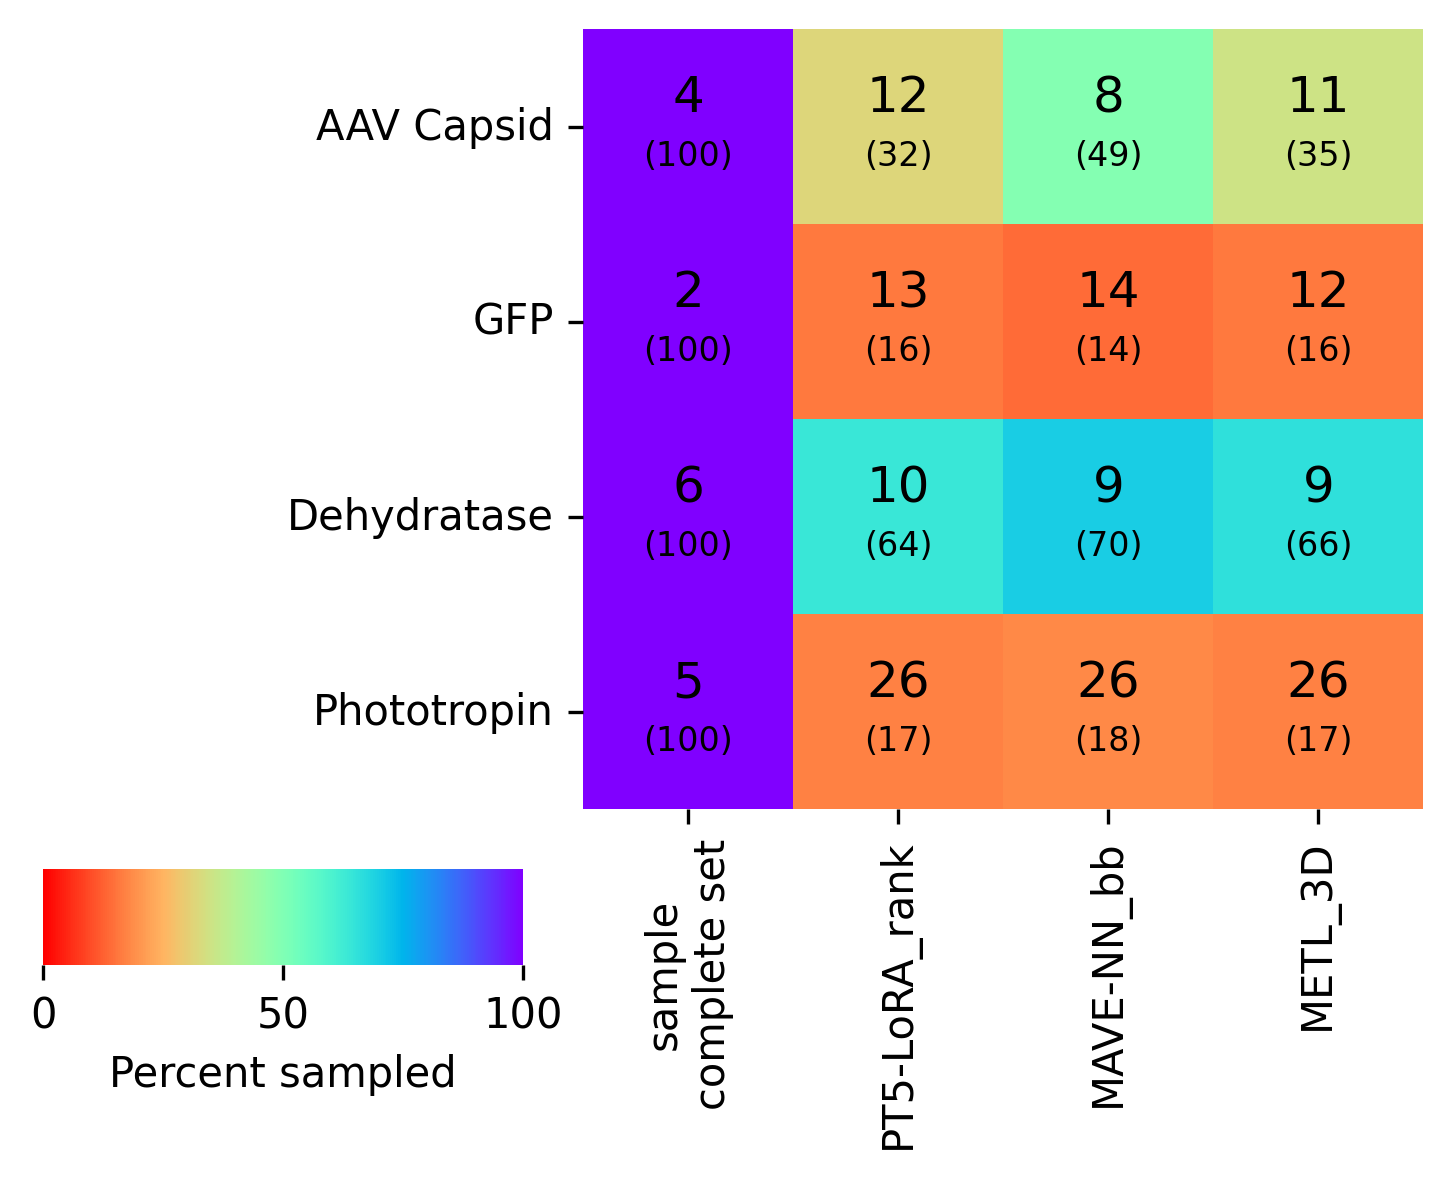

In [32]:
# Panel b

# Ensure numeric values
df_precision_num = df_precision_top10p.apply(pd.to_numeric, errors="coerce")
df_sampling_num = df_sampling_top10p.apply(pd.to_numeric, errors="coerce")

fig = plt.figure(figsize=(4, 4), dpi=300)

# Main heatmap axis
ax = fig.add_axes([0.25, 0.28, 0.7, 0.65])

# Custom colorbar axis in bottom-left area
cbar_ax = fig.add_axes([-0.2, 0.15, 0.4, 0.08])

sns.heatmap(
    df_sampling_num,   # or df_precision_num if color should come from precision
    annot=False,
    fmt="",
    cmap="rainbow_r",
    vmin=0,
    vmax=100,
    cbar=True,
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws={
        "label": "Percent sampled",
        "orientation": "horizontal"
    }
)

# Add custom annotations
for i in range(df_sampling_num.shape[0]):
    for j in range(df_sampling_num.shape[1]):
        samp = df_precision_num.iloc[i, j]
        prec = df_sampling_num.iloc[i, j]

        if pd.notna(samp):
            ax.text(
                j + 0.5, i + 0.35, f"{samp:.0f}",
                ha="center", va="center",
                fontsize=12, color="black"
            )
        if pd.notna(prec):
            ax.text(
                j + 0.5, i + 0.65, f"({prec:.0f})",
                ha="center", va="center",
                fontsize=8, color="black"
            )
ax.set_yticklabels(added_names)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")

plt.show()

### Fig. S10

In [33]:
# create df
plot_dfs = []

for data_select in data:
    
    # load data
    df_all = pd.DataFrame()

    for i, m in enumerate(models_select):
        if i == 0:
            df_all = load_results(data_select, "./results/main/" + m)
            cols_with_seed = [col for col in df_all.columns if 'seed' in col]
            df_all = df_all[[col for col in df_all.columns if col not in cols_with_seed] + cols_with_seed]
            df_all.loc[:, m + '_mean'] = df_all[cols_with_seed].mean(axis=1)
            for c in cols_with_seed:
                df_all.rename(columns={c: m + "_" + c}, inplace=True)
        else:
            df = load_results(data_select, "./results/main/" + m)
            cols_with_seed = [col for col in df.columns if 'seed' in col]
            for c in cols_with_seed:
                df_all.loc[:, m + "_" + c] = df[c]
            df_all.loc[:, m + '_mean'] = df[cols_with_seed].mean(axis=1)

    # keep test set
    df = df_all[df_all.set == "test"].copy()

    # preserve row identity
    df = df.reset_index().rename(columns={"index": "variant_id"})
        
    top100_mask = df["DMS_score"] >= df["DMS_score"].nlargest(100).iloc[-1]
    df["score_norm"] = np.nan

    r = df.loc[top100_mask, "DMS_score"].rank(method="first")
    df.loc[top100_mask, "score_norm"] = (r - 1) / (len(r) - 1)


    rows = []

    top100_true = df.nlargest(100, "DMS_score").copy()
    top100_ids = set(top100_true["variant_id"])

    mean_columns = [col for col in df.columns if col.endswith("_mean")]
    top96_ids = []

    model_tmp_list = []

    for column in mean_columns:
        label = column.rsplit("_", 1)[0]
        top96_model = df.sort_values(by=column, ascending=False).head(96).copy()
        top96_model["is_top100"] = top96_model["variant_id"].isin(top100_ids)

        top96_ids.extend(top96_model["variant_id"].tolist())

        tmp = top96_model[["variant_id", "mutation_depth", "DMS_score", "score_norm", "is_top100"]].copy()
        tmp["dataset"] = data_select
        tmp["model"] = label
        tmp["is_top96"] = True

        model_tmp_list.append(
            tmp.rename(columns={
                "mutation_depth": "depth",
                "DMS_score": "score"
            })
        )

    top96_ids = set(top96_ids)

    # now add top100 with correct is_top96 annotation
    tmp = top100_true[["variant_id", "mutation_depth", "DMS_score", "score_norm"]].copy()
    tmp["dataset"] = data_select
    tmp["model"] = "top100"
    tmp["is_top100"] = True
    tmp["is_top96"] = tmp["variant_id"].isin(top96_ids)

    rows.append(
        tmp.rename(columns={
            "mutation_depth": "depth",
            "DMS_score": "score"
        })
    )

    rows.extend(model_tmp_list)

    df_plot_dataset = pd.concat(rows, ignore_index=True)
    plot_dfs.append(df_plot_dataset)

df_plot = pd.concat(plot_dfs, ignore_index=True)

In [34]:
# get numbers for identified / not-found top100 variants
df_plot[df_plot["model"] == "top100"].groupby("dataset")["is_top96"].value_counts().unstack(fill_value=0).rename(columns={True: "is_top96", False: "is_not96"})

is_top96,is_not96,is_top96
dataset,,
CAPSD_AAV2S_Sinai_2021,72,28
GFP_AEQVI_Sarkisyan_2016,57,43
HIS7_YEAST_Pokusaeva_2019,100,0
PHOT_CHLRE_Chen_2023,75,25


In [35]:
# get number of hits for individual models
df_plot.groupby(["dataset", "model"])["is_top100"].sum().unstack(fill_value=0)

model,MAVE-NN_bb,METL_3D,PT5-LoRA_rank,top100
dataset,,,,
CAPSD_AAV2S_Sinai_2021,0,19,20,100
GFP_AEQVI_Sarkisyan_2016,26,10,28,100
HIS7_YEAST_Pokusaeva_2019,0,0,0,100
PHOT_CHLRE_Chen_2023,16,19,16,100


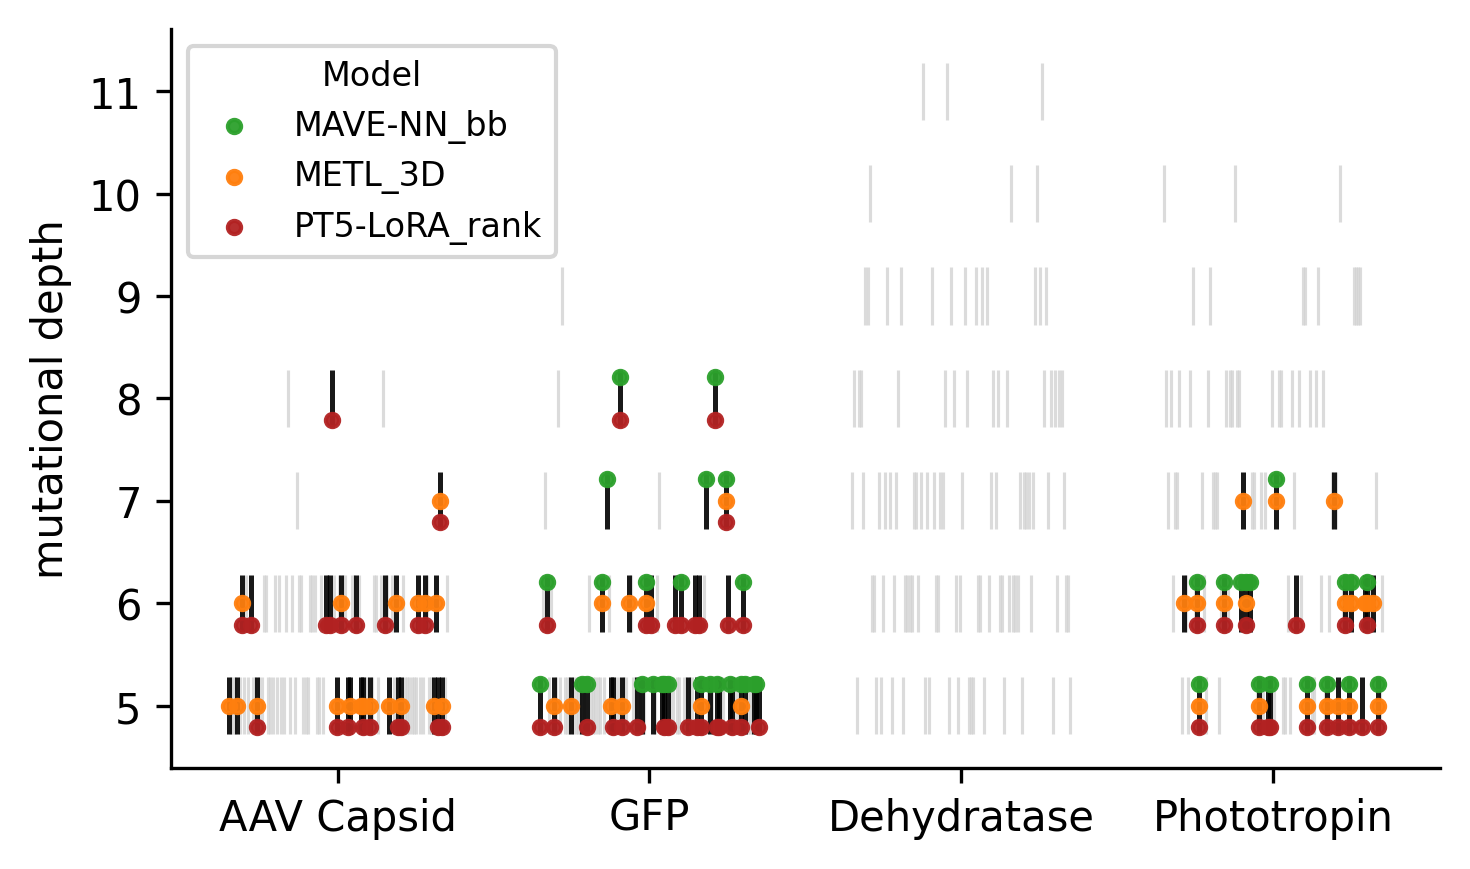

In [36]:
# plot
added_names = ["AAV Capsid", "GFP", "Dehydratase", "Phototropin"]

top_df = df_plot[df_plot["model"] == "top100"].copy()

datasets = list(top_df["dataset"].unique())
x_pos = {d: i for i, d in enumerate(datasets)}

# spread within each dataset by normalized DMS score
jitter_width = 0.35
top_df["x"] = top_df["dataset"].map(x_pos) + (top_df["score_norm"] - 0.5) * 2 * jitter_width

found = top_df[top_df["is_top96"]].copy()
not_found = top_df[~top_df["is_top96"]].copy()

fig, ax = plt.subplots(figsize=(len(datasets) + 1, 3), dpi=300)

# vertical line half-length
line_half = 0.28

# grey thin vertical lines = top100 not found
ax.vlines(
    not_found["x"],
    not_found["depth"] - line_half,
    not_found["depth"] + line_half,
    colors="lightgrey",
    linewidth=0.75,
    alpha=0.8,
    zorder=1
)

# black thin vertical lines = top100 found
ax.vlines(
    found["x"],
    found["depth"] - line_half,
    found["depth"] + line_half,
    colors="black",
    linewidth=1.2,
    alpha=0.9,
    zorder=2
)

# only model hits
model_df = df_plot[(df_plot["model"] != "top100") & (df_plot["is_top100"])].copy()

model_order = sorted(model_df["model"].unique())
color_map = {
    model_order[0]: "tab:green",
    model_order[1]: "tab:orange",
    model_order[2]: "firebrick",
}

# map each found mutation by dataset + score_norm + depth to its x center
found_key_cols = ["dataset", "score_norm", "depth"]
found_centers = found[found_key_cols + ["x"]].copy()

model_df = model_df.merge(
    found_centers,
    on=found_key_cols,
    how="left",
    suffixes=("", "_center")
)

# vertical positions along the black line: top / mid / lower
y_offsets = {
    model_order[0]: line_half * 0.75,   # top
    model_order[1]: 0.0,                # middle
    model_order[2]: -line_half * 0.75,  # lower
}

model_df["x_plot"] = model_df["x"] 
model_df["y_plot"] = model_df["depth"] + model_df["model"].map(y_offsets)

for model in model_order:
    sub = model_df[model_df["model"] == model]

    ax.scatter(
        sub["x_plot"],
        sub["y_plot"],
        s=10,
        c=color_map[model],
        alpha=0.95,
        zorder=3,
        label=model
    )

ax.set_xticks(range(len(datasets)))
ax.set_xticklabels(added_names, ha="center")
ax.set_ylabel("mutational depth")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=True,loc="upper left", fontsize=8, title="Model",   title_fontsize=8)
plt.tight_layout()
plt.show()


## Tables

### Table S2-S5

In [37]:
def dataset_size(data):
    
    print(data)
    
    df_raw = pd.read_csv("./data/raw/" + data + "/DMS_raw.csv", low_memory=False) 

    df_raw = df_raw[df_raw.set!="wt"]    
    df_raw = df_raw.drop('mutated_sequence', axis=1)
    df_raw = df_raw.drop('set', axis=1)

    df_func = df_raw[df_raw.DMS_score_bin == 1].copy()
    
    if "ss" in data:
        buckets = [range(1,4), range(4,5), range(5,8), range(8,df_raw.mutation_depth.max()+1)]
        distance_wt  = ["1-3", "4", "5-7", "8-" + str(df_raw.mutation_depth.max())]
    else:
        buckets = [range(1,4), range(4,5), range(5,10), range(10,df_raw.mutation_depth.max()+1)]
        distance_wt  = ["1-3", "4", "5-9", "10-" + str(df_raw.mutation_depth.max())]
    split  = ["Training", "Validation", "Test", "Test"]



    res = pd.DataFrame(columns=["Split","Distance from wildtype", "Distance Bin","Number of seq","Number of functional seq","Share of functional seq"])

    for idx , b in enumerate(buckets):
        if idx == len(buckets) -1:
            if "GFP" in data:
                cutoff = 10
            else:
                cutoff = get_cutoff(data)

            for i in range(np.min(b),cutoff):
                new_row = pd.DataFrame([{'Split' : split[idx],
                                         "Distance from wildtype" : i,
                                         'Distance bin' : distance_wt[idx],
                                         'Number of seq' : len(df_raw[df_raw.mutation_depth == i]),
                                         'Number of functional seq' : len(df_func[df_func.mutation_depth == i]),
                                         'Share of functional seq' :  round(len(df_func[df_func.mutation_depth == i]) / 
                                                                         len(df_raw[df_raw.mutation_depth == i]),3) *100
                                        }])
                res = pd.concat([res.dropna(how='all', axis=1),new_row], ignore_index=True)
                
            new_row = pd.DataFrame([{'Split' : split[idx],
                                     "Distance from wildtype" : str(cutoff) + "-" + str(df_raw.mutation_depth.max()),
                                     'Distance bin' : distance_wt[idx],
                                     'Number of seq' : len(df_raw[df_raw.mutation_depth >= cutoff]),
                                     'Number of functional seq' : len(df_func[df_func.mutation_depth >= cutoff]),
                                     'Share of functional seq' :  round(len(df_func[df_func.mutation_depth >= cutoff]) / 
                                                                     len(df_raw[df_raw.mutation_depth >= cutoff]),3) *100
                                    }])            
            
            res = pd.concat([res.dropna(how='all', axis=1),new_row], ignore_index=True)            
        else:
            for i in range(np.min(b),np.max(b)+1):
                new_row = pd.DataFrame([{'Split' : split[idx],
                                         "Distance from wildtype" : i,
                                         'Distance bin' : distance_wt[idx],
                                         'Number of seq' : len(df_raw[df_raw.mutation_depth == i]),
                                         'Number of functional seq' : len(df_func[df_func.mutation_depth == i]),
                                         'Share of functional seq' :  round(len(df_func[df_func.mutation_depth == i]) / 
                                                                         len(df_raw[df_raw.mutation_depth == i]),3) *100
                                        }])
                res = pd.concat([res.dropna(how='all', axis=1),new_row], ignore_index=True)
                
    if "GFP" in data:
        res.loc[7:,"Distance bin"] = "8-15"
    
    return(res)
    


In [38]:
dataset_size(files[0])

CAPSD_AAV2S_Sinai_2021


,Split,Distance from wildtype,Distance bin,Number of seq,Number of functional seq,Share of functional seq
0,Training,1,1-3,532,315,59.2
1,Training,2,1-3,10833,4601,42.5
2,Training,3,1-3,6906,5177,75.0
3,Validation,4,4,6646,4504,67.8
4,Test,5,5-9,6298,3772,59.9
5,Test,6,5-9,5396,2584,47.9
6,Test,7,5-9,858,398,46.4
7,Test,8,5-9,739,237,32.1
8,Test,9,5-9,651,141,21.7
9,Test,10,10-28,583,92,15.8


In [39]:
dataset_size(files[1])

GFP_AEQVI_Sarkisyan_2016


,Split,Distance from wildtype,Distance bin,Number of seq,Number of functional seq,Share of functional seq
0,Training,1,1-3,1084,993,91.6
1,Training,2,1-3,12777,11367,89.0
2,Training,3,1-3,12336,9234,74.9
3,Validation,4,4,9387,5104,54.4
4,Test,5,5-9,6825,2284,33.5
5,Test,6,5-9,4298,802,18.7
6,Test,7,5-9,2526,229,9.1
7,Test,8,8-15,1364,61,4.5
8,Test,9,8-15,627,10,1.6
9,Test,10-15,8-15,490,2,0.4


In [40]:
dataset_size(files[2])

HIS7_YEAST_Pokusaeva_2019


,Split,Distance from wildtype,Distance bin,Number of seq,Number of functional seq,Share of functional seq
0,Training,1,1-3,168,162,96.4
1,Training,2,1-3,1475,1375,93.2
2,Training,3,1-3,7627,6661,87.3
3,Validation,4,4,25927,21177,81.7
4,Test,5,5-9,60263,45987,76.3
5,Test,6,5-9,98869,70269,71.1
6,Test,7,5-9,115751,76096,65.7
7,Test,8,5-9,97639,58953,60.4
8,Test,9,5-9,57139,32216,56.4
9,Test,10,10-28,22942,12488,54.4


In [41]:
dataset_size(files[3])

PHOT_CHLRE_Chen_2023


,Split,Distance from wildtype,Distance bin,Number of seq,Number of functional seq,Share of functional seq
0,Training,1,1-3,2122,1828,86.1
1,Training,2,1-3,176,168,95.5
2,Training,3,1-3,978,856,87.5
3,Validation,4,4,3565,2859,80.2
4,Test,5,5-9,9603,7015,73.1
5,Test,6,5-9,19193,12518,65.2
6,Test,7,5-9,29255,16938,57.9
7,Test,8,5-9,34230,17071,49.9
8,Test,9,5-9,30925,13010,42.1
9,Test,10,10-15,21167,7361,34.8


### Table S6-S9

In [42]:
models = ['SBI',
         '1-hot',
         'MAVE-NN_add',
         'MAVE-NN_bb',
         'PT5-LoRA_reg',
         'PT5-LoRA_rank',
         'PT5-Emb',
         'PT5-Emb_evo',
         'METL_1D',
         'METL_3D']

metrics = ["AUCPR","spearman_func","TOP_10", "NDCG@10"]

In [43]:
# read results from file
pd.read_csv("./results/main/random_baseline/CAPSD_AAV2S_Sinai_2021_only.csv")

# # alternatively compute metrics without random baseline
# table_multi_model_multi_metric_DeePEn(methods = models, 
#                                       datas = ['CAPSD_AAV2S_Sinai_2021'], 
#                                       metric = metrics, 
#                                       main = True, 
#                                       percentage = True, 
#                                       digits = 2)

,method,depth,AUCPR,spearman_func,TOP_10,NDCG@10
0,perfect_classifier_baseline,shallow (5-9),100 ± 0,0 ± 0,10 ± 0,72 ± 0
1,perfect_classifier_baseline,higher depth (10+),100 ± 0,0 ± 1,10 ± 1,75 ± 0
2,random_baseline,shallow (5-9),42 ± 0,0 ± 0,4 ± 0,30 ± 0
3,random_baseline,higher depth (10+),10 ± 0,0 ± 1,1 ± 0,7 ± 1
4,SBI,shallow (5-9),62 ± 0,19 ± 0,15 ± 0,50 ± 0
5,SBI,higher depth (10+),17 ± 0,3 ± 0,0 ± 0,18 ± 0
6,1-hot,shallow (5-9),48 ± 8,-4 ± 14,4 ± 6,34 ± 14
7,1-hot,higher depth (10+),12 ± 5,-1 ± 18,0 ± 0,5 ± 10
8,MAVE-NN_add,shallow (5-9),77 ± 0,28 ± 3,16 ± 3,68 ± 2
9,MAVE-NN_add,higher depth (10+),26 ± 1,15 ± 2,17 ± 0,37 ± 7


In [44]:
# read results from file
pd.read_csv("./results/main/random_baseline/HIS7_YEAST_Pokusaeva_2019_only.csv")

# # alternatively compute metrics without random baseline
# table_multi_model_multi_metric_DeePEn(methods = models, 
#                                       datas = ['HIS7_YEAST_Pokusaeva_2019'], 
#                                       metric = metrics, 
#                                       main = True, 
#                                       percentage = True, 
#                                       digits = 2)

,method,depth,AUCPR,spearman_func,TOP_10,NDCG@10
0,perfect_classifier_baseline,shallow (5-9),100 ± 0,0 ± 0,10 ± 0,89 ± 0
1,perfect_classifier_baseline,higher depth (10+),100 ± 0,0 ± 0,10 ± 0,87 ± 0
2,random_baseline,shallow (5-9),66 ± 0,0 ± 0,7 ± 0,59 ± 0
3,random_baseline,higher depth (10+),53 ± 0,0 ± 0,5 ± 0,46 ± 0
4,SBI,shallow (5-9),82 ± 0,10 ± 0,12 ± 0,76 ± 0
5,SBI,higher depth (10+),65 ± 0,3 ± 0,8 ± 0,56 ± 0
6,1-hot,shallow (5-9),76 ± 2,3 ± 4,9 ± 1,62 ± 7
7,1-hot,higher depth (10+),62 ± 3,6 ± 17,5 ± 3,36 ± 10
8,MAVE-NN_add,shallow (5-9),87 ± 1,9 ± 2,6 ± 1,90 ± 1
9,MAVE-NN_add,higher depth (10+),49 ± 2,-9 ± 2,1 ± 0,50 ± 2


In [45]:
# read results from file
pd.read_csv("./results/main/random_baseline/GFP_AEQVI_Sarkisyan_2016_only.csv")

# # alternatively compute metrics without random baseline
# table_multi_model_multi_metric_DeePEn(methods = models, 
#                                       datas = ['GFP_AEQVI_Sarkisyan_2016'], 
#                                       metric = ["spearman_all"] + metrics, 
#                                       main = True, 
#                                       percentage = True, 
#                                       digits = 2)

,method,depth,spearman_all,AUCPR,spearman_func,TOP_10,NDCG@10
0,perfect_classifier_baseline,shallow (5-9),65 ± 0,100 ± 0,0 ± 0,10 ± 0,83 ± 0
1,perfect_classifier_baseline,higher depth (10+),28 ± 0,100 ± 0,-1 ± 1,9 ± 1,83 ± 0
2,random_baseline,shallow (5-9),0 ± 0,21 ± 0,0 ± 0,2 ± 0,17 ± 0
3,random_baseline,higher depth (10+),0 ± 0,3 ± 0,-1 ± 1,0 ± 0,3 ± 0
4,SBI,shallow (5-9),27 ± 0,37 ± 0,17 ± 0,7 ± 0,40 ± 0
5,SBI,higher depth (10+),2 ± 0,8 ± 0,28 ± 0,0 ± 0,12 ± 0
6,1-hot,shallow (5-9),-2 ± 13,20 ± 6,-1 ± 11,1 ± 1,14 ± 23
7,1-hot,higher depth (10+),-1 ± 2,3 ± 1,-8 ± 1,0 ± 0,0 ± 0
8,MAVE-NN_add,shallow (5-9),48 ± 1,97 ± 1,66 ± 1,40 ± 4,95 ± 1
9,MAVE-NN_add,higher depth (10+),6 ± 1,85 ± 2,55 ± 3,52 ± 20,97 ± 1


In [46]:
# read results from file
pd.read_csv("./results/main/random_baseline/PHOT_CHLRE_Chen_2023_only.csv")

# # alternatively compute metrics without random baseline
# table_multi_model_multi_metric_DeePEn(methods = models, 
#                                       datas = ['PHOT_CHLRE_Chen_2023'], 
#                                       metric = metrics, 
#                                       main = True, 
#                                       percentage = True, 
#                                       digits = 2)

,method,depth,AUCPR,spearman_func,TOP_10,NDCG@10
0,perfect_classifier_baseline,shallow (5-9),100 ± 0,0 ± 0,10 ± 0,67 ± 0
1,perfect_classifier_baseline,higher depth (10+),100 ± 0,0 ± 0,10 ± 0,66 ± 0
2,random_baseline,shallow (5-9),57 ± 0,0 ± 0,6 ± 0,39 ± 0
3,random_baseline,higher depth (10+),25 ± 0,0 ± 0,3 ± 0,16 ± 0
4,SBI,shallow (5-9),70 ± 0,36 ± 0,22 ± 0,63 ± 0
5,SBI,higher depth (10+),31 ± 0,22 ± 0,7 ± 0,24 ± 0
6,1-hot,shallow (5-9),62 ± 18,7 ± 19,7 ± 11,45 ± 34
7,1-hot,higher depth (10+),30 ± 22,9 ± 25,4 ± 9,24 ± 44
8,MAVE-NN_add,shallow (5-9),92 ± 0,74 ± 1,59 ± 1,93 ± 0
9,MAVE-NN_add,higher depth (10+),70 ± 1,56 ± 1,46 ± 1,83 ± 1


### Table S10

In [47]:
models = ["PT5-LoRA_rank",
        "PT5-LoRA_rank_evo-tuned",
        "PT5-LoRA_rank_EVA-init"]

In [48]:
df = table_multi_model_multi_metric_DeePEn(models,files,["AUCPR", "spearman_func", "TOP_10", "NDCG@10"], main= False, percentage = True, digits = 2)
df

,method,depth,AUCPR,spearman_func,TOP_10,NDCG@10
0,PT5-LoRA_rank,shallow (5-9),89 ± 2,54 ± 4,38 ± 5,85 ± 6
1,PT5-LoRA_rank,higher depth (10+),74 ± 6,40 ± 10,30 ± 8,70 ± 28
2,PT5-LoRA_rank_evo-tuned,shallow (5-9),89 ± 3,55 ± 4,38 ± 4,85 ± 6
3,PT5-LoRA_rank_evo-tuned,higher depth (10+),74 ± 8,38 ± 5,28 ± 8,71 ± 22
4,PT5-LoRA_rank_EVA-init,shallow (5-9),89 ± 1,55 ± 3,38 ± 4,86 ± 4
5,PT5-LoRA_rank_EVA-init,higher depth (10+),72 ± 6,39 ± 9,28 ± 6,65 ± 13


### Table S11

In [49]:
models = ["PT5-LoRA_reg",
        "PT5-LoRA_rank",
        "PT5-LoRA_rank_contrastive",             
        "PT5-LoRA_rank_contrastive_onesided",
        "PT5-LoRA_rank_lambda_rank"]

In [50]:
# table S11
df = table_multi_model_multi_metric_DeePEn(models,files,["AUCPR", "spearman_func", "TOP_10", "NDCG@10"], main= False, percentage = True, digits = 2)
df

,method,depth,AUCPR,spearman_func,TOP_10,NDCG@10
0,PT5-LoRA_reg,shallow (5-9),90 ± 3,53 ± 4,37 ± 6,85 ± 7
1,PT5-LoRA_reg,higher depth (10+),75 ± 11,36 ± 8,28 ± 13,70 ± 19
2,PT5-LoRA_rank,shallow (5-9),89 ± 2,54 ± 4,38 ± 5,85 ± 6
3,PT5-LoRA_rank,higher depth (10+),74 ± 6,40 ± 10,30 ± 8,70 ± 28
4,PT5-LoRA_rank_contrastive,shallow (5-9),89 ± 3,54 ± 5,38 ± 7,86 ± 6
5,PT5-LoRA_rank_contrastive,higher depth (10+),73 ± 5,40 ± 7,31 ± 8,69 ± 14
6,PT5-LoRA_rank_contrastive_onesided,shallow (5-9),88 ± 1,53 ± 4,36 ± 6,85 ± 3
7,PT5-LoRA_rank_contrastive_onesided,higher depth (10+),73 ± 6,39 ± 14,26 ± 11,65 ± 18
8,PT5-LoRA_rank_lambda_rank,shallow (5-9),90 ± 1,54 ± 4,36 ± 7,89 ± 2
9,PT5-LoRA_rank_lambda_rank,higher depth (10+),76 ± 8,39 ± 13,30 ± 10,78 ± 15


### Table S12

In [51]:
models = ['SBI',
         '1-hot',
         'MAVE-NN_add',
         'MAVE-NN_bb',
         'PT5-LoRA_reg',
         'PT5-LoRA_rank',
         'PT5-Emb',
         'PT5-Emb_evo',
         'METL_1D',
         'METL_3D']

metrics = ["TOP_5", "TOP_10", "TOP_15", "TOP_20", "TOP_25", "TOP_30"]

In [57]:
# table S12
df = table_multi_model_multi_metric_DeePEn(models,files,metrics, main= True, 
                                           random_baseline = True, perfect_classifier_baseline = True,
                                           percentage = True, digits = 2)
df

,method,depth,TOP_5,TOP_10,TOP_15,TOP_20,TOP_25,TOP_30
0,perfect_classifier_baseline,shallow (5-9),5 ± 0,10 ± 0,15 ± 0,20 ± 0,25 ± 0,30 ± 0
1,perfect_classifier_baseline,higher depth (10+),5 ± 0,10 ± 0,15 ± 0,20 ± 0,25 ± 0,30 ± 0
2,random_baseline,shallow (5-9),2 ± 0,5 ± 0,7 ± 0,10 ± 0,12 ± 0,15 ± 0
3,random_baseline,higher depth (10+),1 ± 0,3 ± 0,5 ± 0,6 ± 0,8 ± 0,9 ± 0
4,SBI,shallow (5-9),9 ± 0,15 ± 0,19 ± 0,23 ± 0,25 ± 0,28 ± 0
5,SBI,higher depth (10+),5 ± 0,5 ± 0,8 ± 0,9 ± 0,11 ± 0,13 ± 0
6,1-hot,shallow (5-9),2 ± 3,6 ± 5,9 ± 6,11 ± 7,14 ± 8,17 ± 8
7,1-hot,higher depth (10+),2 ± 4,3 ± 4,5 ± 6,7 ± 8,9 ± 9,11 ± 10
8,MAVE-NN_add,shallow (5-9),23 ± 2,28 ± 2,35 ± 2,39 ± 1,43 ± 1,48 ± 2
9,MAVE-NN_add,higher depth (10+),21 ± 2,25 ± 2,24 ± 0,26 ± 1,28 ± 1,30 ± 2
